In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import missingno as msno
from matplotlib.gridspec import GridSpec
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
from pathlib import Path

# The Purpose of this EDA is to Perform Univariate , Bivariate , Multivariate Analysis which will eventually help me to perform Feature Engineering and Imputing Missing Values

In [93]:
root_dir = Path.cwd().parent

In [94]:
data_dir = root_dir / "data" / "interim"

In [95]:
df = pd.read_csv(data_dir / "urbaneats-cleaned-dataset.csv")

In [96]:
df.sample(10)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city,order_day,order_month,order_day_of_week,is_weekend,order_time_hour,pickup_time_minutes,order_time_of_day,distance
32700,PUNERES16DEL02,29.0,4.5,18.536718,73.830327,18.616719,73.910327,2022-03-04,sandstorms,jam,...,19,PUNE,4,3,Friday,0,19.0,15.0,evening,12.257003
5296,HYDRES08DEL02,37.0,4.5,17.438263,78.397865,17.518263,78.477865,2022-03-06,stormy,jam,...,36,HYD,6,3,Sunday,1,20.0,10.0,evening,12.293290
39120,COIMBRES09DEL01,33.0,4.6,11.008638,76.984311,11.048638,77.024311,2022-03-19,fog,medium,...,18,COIMB,19,3,Saturday,1,15.0,15.0,afternoon,6.232321
7549,VADRES02DEL02,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-03,cloudy,medium,...,13,VAD,3,4,Sunday,1,NaN,NaN,NaN,NaN
22949,COIMBRES20DEL01,31.0,4.7,10.994136,76.963303,11.104136,77.073303,2022-03-10,windy,medium,...,30,COIMB,10,3,Thursday,0,18.0,15.0,evening,17.138296
5837,CHENRES04DEL02,35.0,4.8,13.029780,80.208812,13.079780,80.258812,2022-03-11,sandstorms,low,...,27,CHEN,11,3,Friday,0,23.0,10.0,night,7.761726
33663,PUNERES17DEL02,28.0,4.6,18.530963,73.828972,18.550963,73.848972,2022-03-24,cloudy,low,...,10,PUNE,24,3,Thursday,0,10.0,15.0,morning,3.064535
37595,PUNERES06DEL01,21.0,4.8,18.546258,73.904337,18.616258,73.974337,2022-04-04,windy,medium,...,27,PUNE,4,4,Monday,0,17.0,15.0,afternoon,10.724672
31242,AURGRES13DEL02,25.0,4.4,19.880256,75.323503,19.960256,75.403503,2022-02-14,stormy,medium,...,39,AURG,14,2,Monday,0,17.0,10.0,afternoon,12.209718
45441,COIMBRES12DEL02,39.0,4.8,11.000762,76.981876,11.050762,77.031876,2022-03-28,windy,low,...,21,COIMB,28,3,Monday,0,22.0,15.0,night,7.790439


# Preliminary Analysis

In [97]:
df.isna().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city                       0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
order_time_hour         1640
pickup_time_minutes     1640
order_time_of_day       2070
distance                3630
dtype: int64

In [98]:
# Missing # of rows
# Rows which have atleast 1 col missing
df.isna().any(axis=1).sum()

np.int64(7807)

In [99]:
# Missing % of rows
missing_rows = (
    df
    .isnull()
    .any(axis=1)
    .sum()
)

print(f'There are {missing_rows} rows with missing values in the data.')

print(f"It accounts for {(missing_rows/df.shape[0])*100:.2f}% of the data")

There are 7807 rows with missing values in the data.
It accounts for 17.16% of the data


**The initial percentage of missing data was `9.2%` and increased to `16.35%` because we transformed 0 values in the lat long columns to NaN**

In [100]:
df.duplicated().sum()

np.int64(0)

In [101]:
col_to_convert = ['vehicle_condition','multiple_deliveries','order_time_hour','order_time_of_day','order_day','order_month','is_weekend']

In [102]:
for col in col_to_convert:
    df[col] = df[col].astype(object)

In [103]:
df.dtypes

rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
weather                  object
traffic                  object
vehicle_condition        object
type_of_order            object
type_of_vehicle          object
multiple_deliveries      object
festival                 object
city_type                object
time_taken                int64
city                     object
order_day                object
order_month              object
order_day_of_week        object
is_weekend               object
order_time_hour          object
pickup_time_minutes     float64
order_time_of_day        object
distance                float64
dtype: object

In [104]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f"There are {len(cat_cols)} categorical columns and {len(num_cols)} numerical columns in the dataset.")

There are 17 categorical columns and 9 numerical columns in the dataset.


In [105]:
num_cols

['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'time_taken',
 'pickup_time_minutes',
 'distance']

In [106]:
cat_cols

['rider_id',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day']

In [107]:
df[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutes,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,26.297591,9.989399,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,9.386419,4.087516,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,5.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,26.000000,10.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,32.000000,15.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [108]:
df[cat_cols].describe(include='object').T

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
vehicle_condition,45502,4,2,15034
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
multiple_deliveries,44509.0,4.0,1.0,28109.0
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029


# Missing Value Analysis

<Axes: >

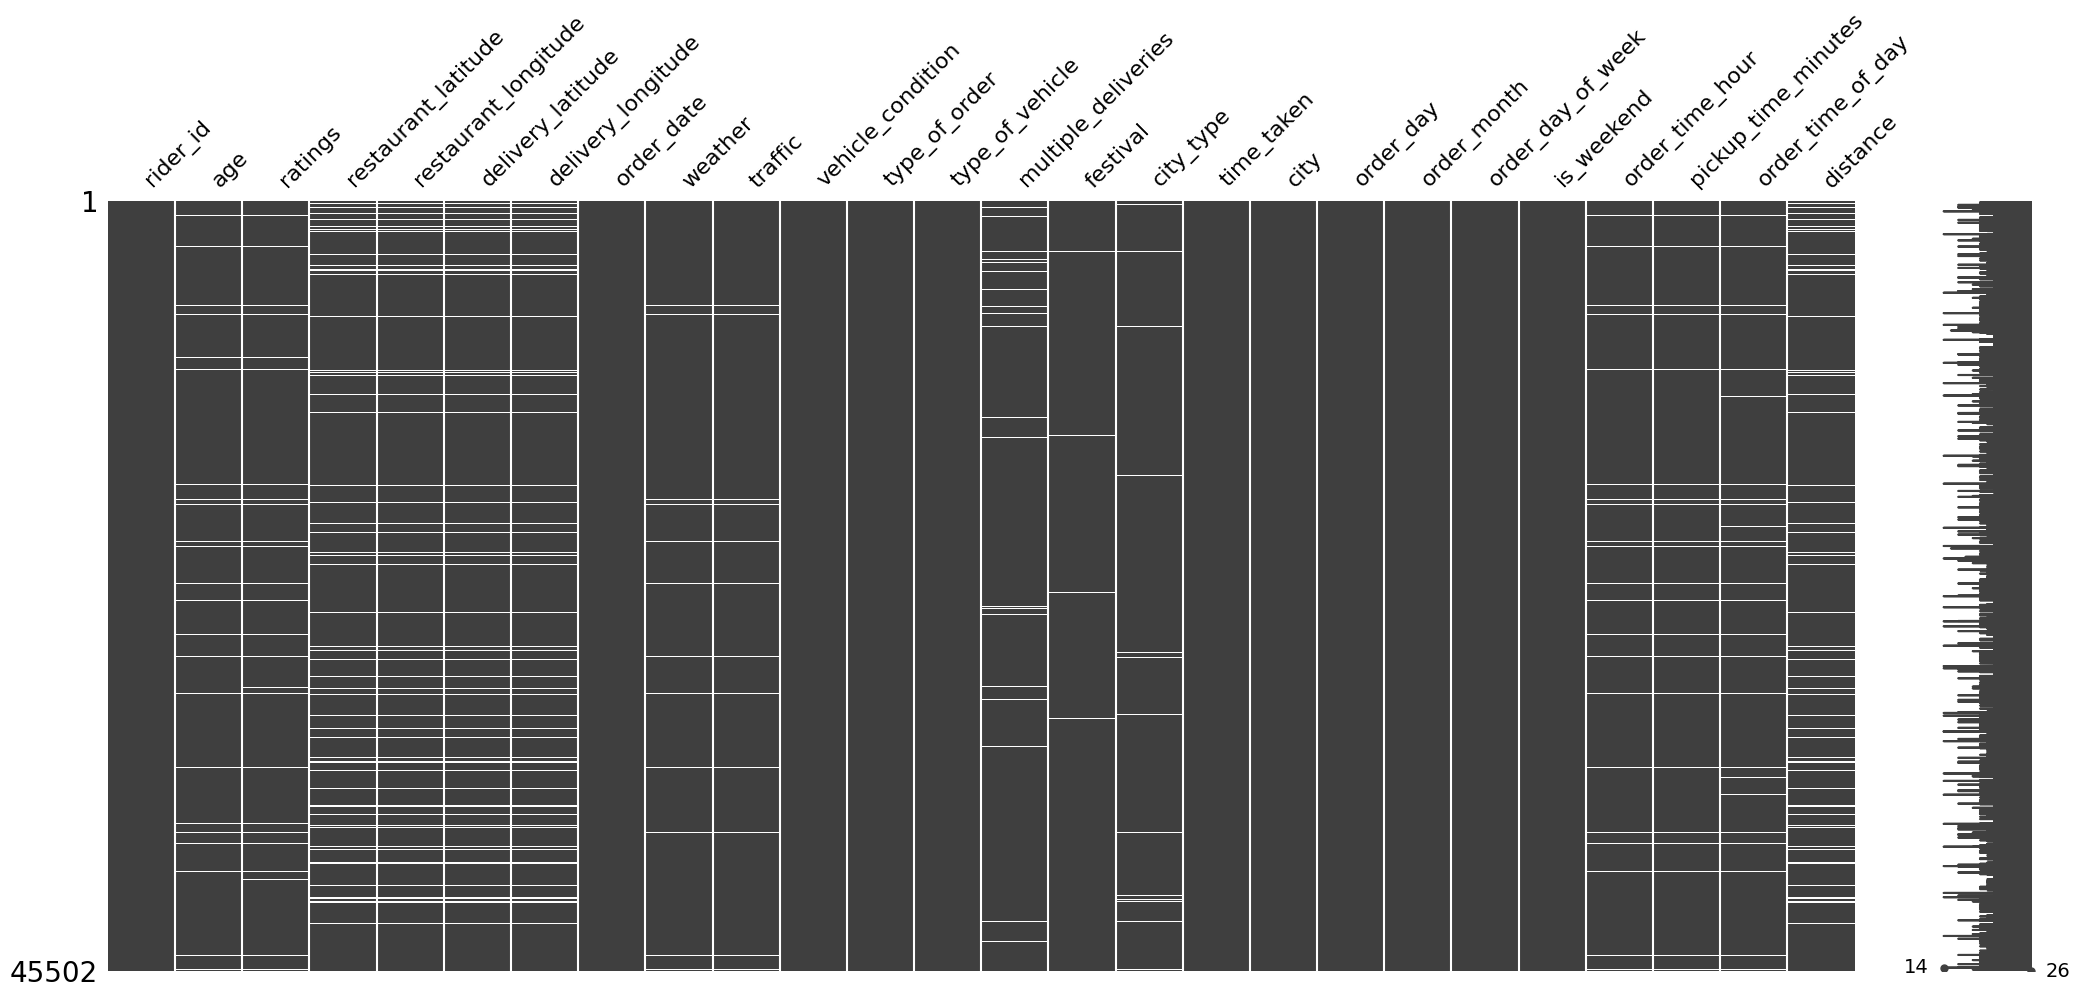

In [109]:
msno.matrix(df)

<Axes: >

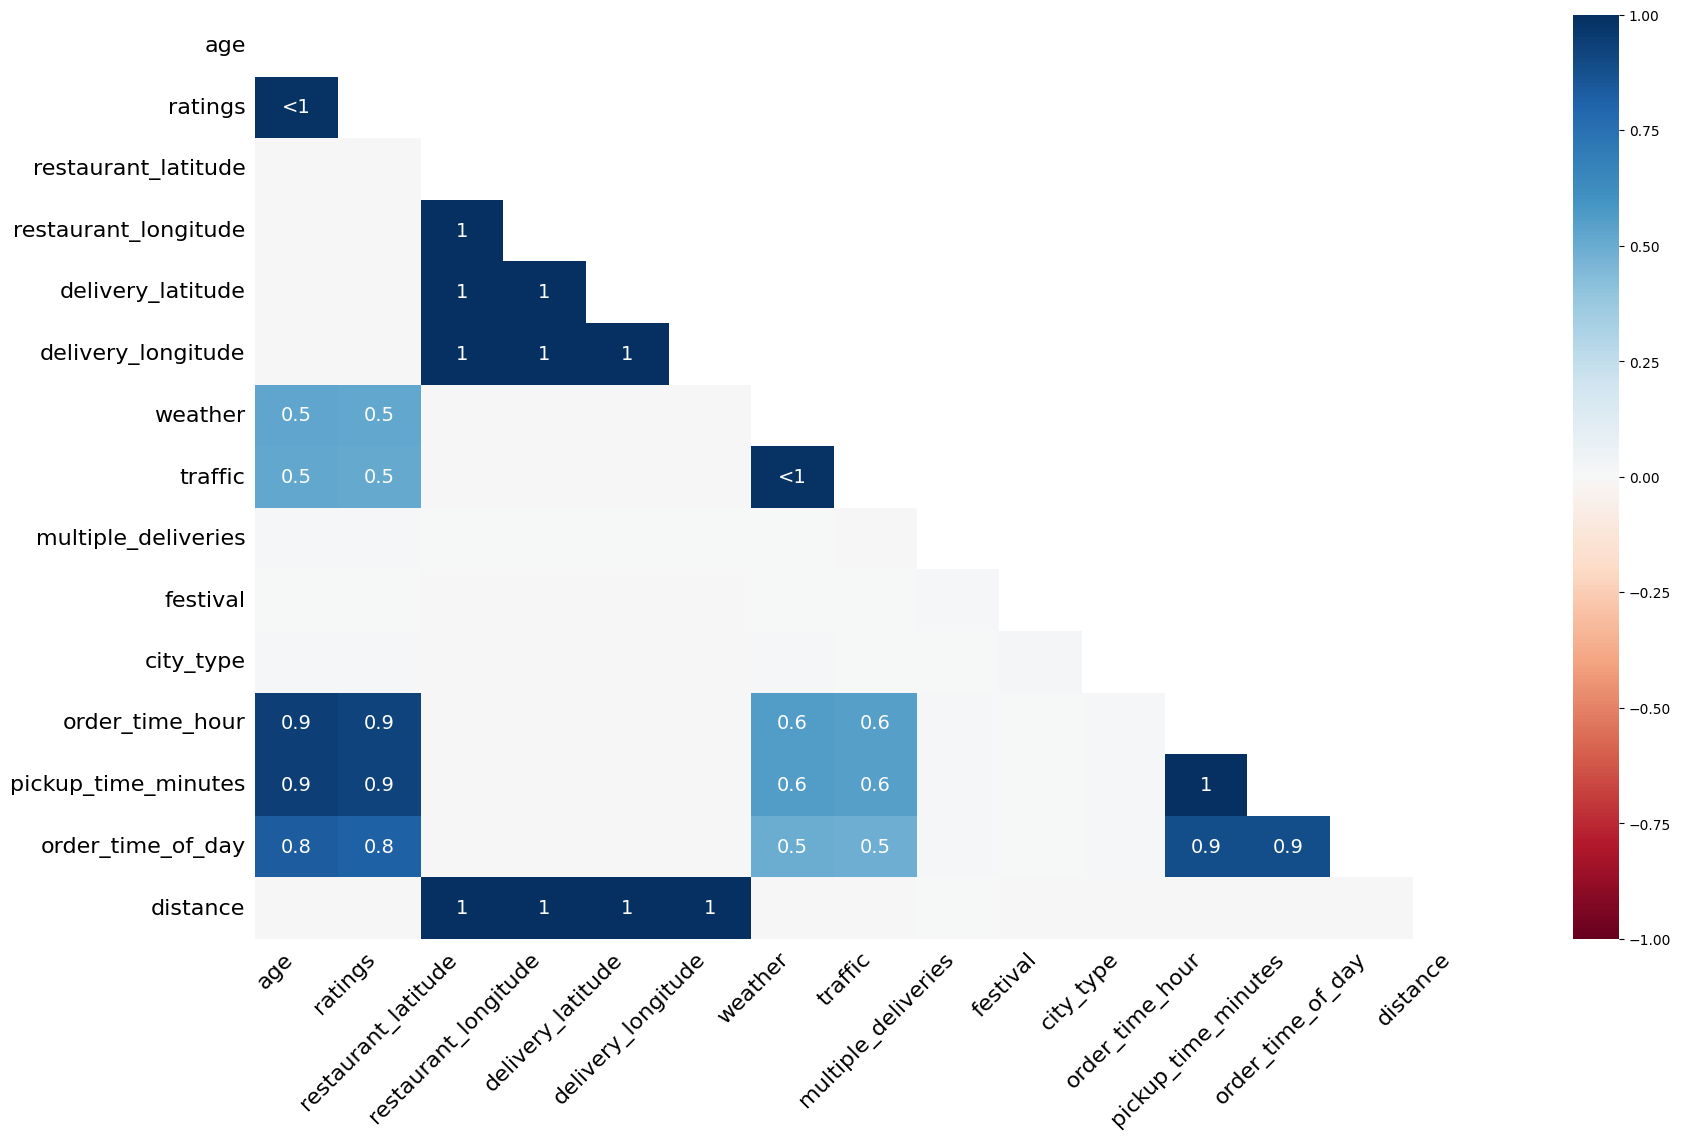

In [110]:
msno.heatmap(df)

<Axes: >

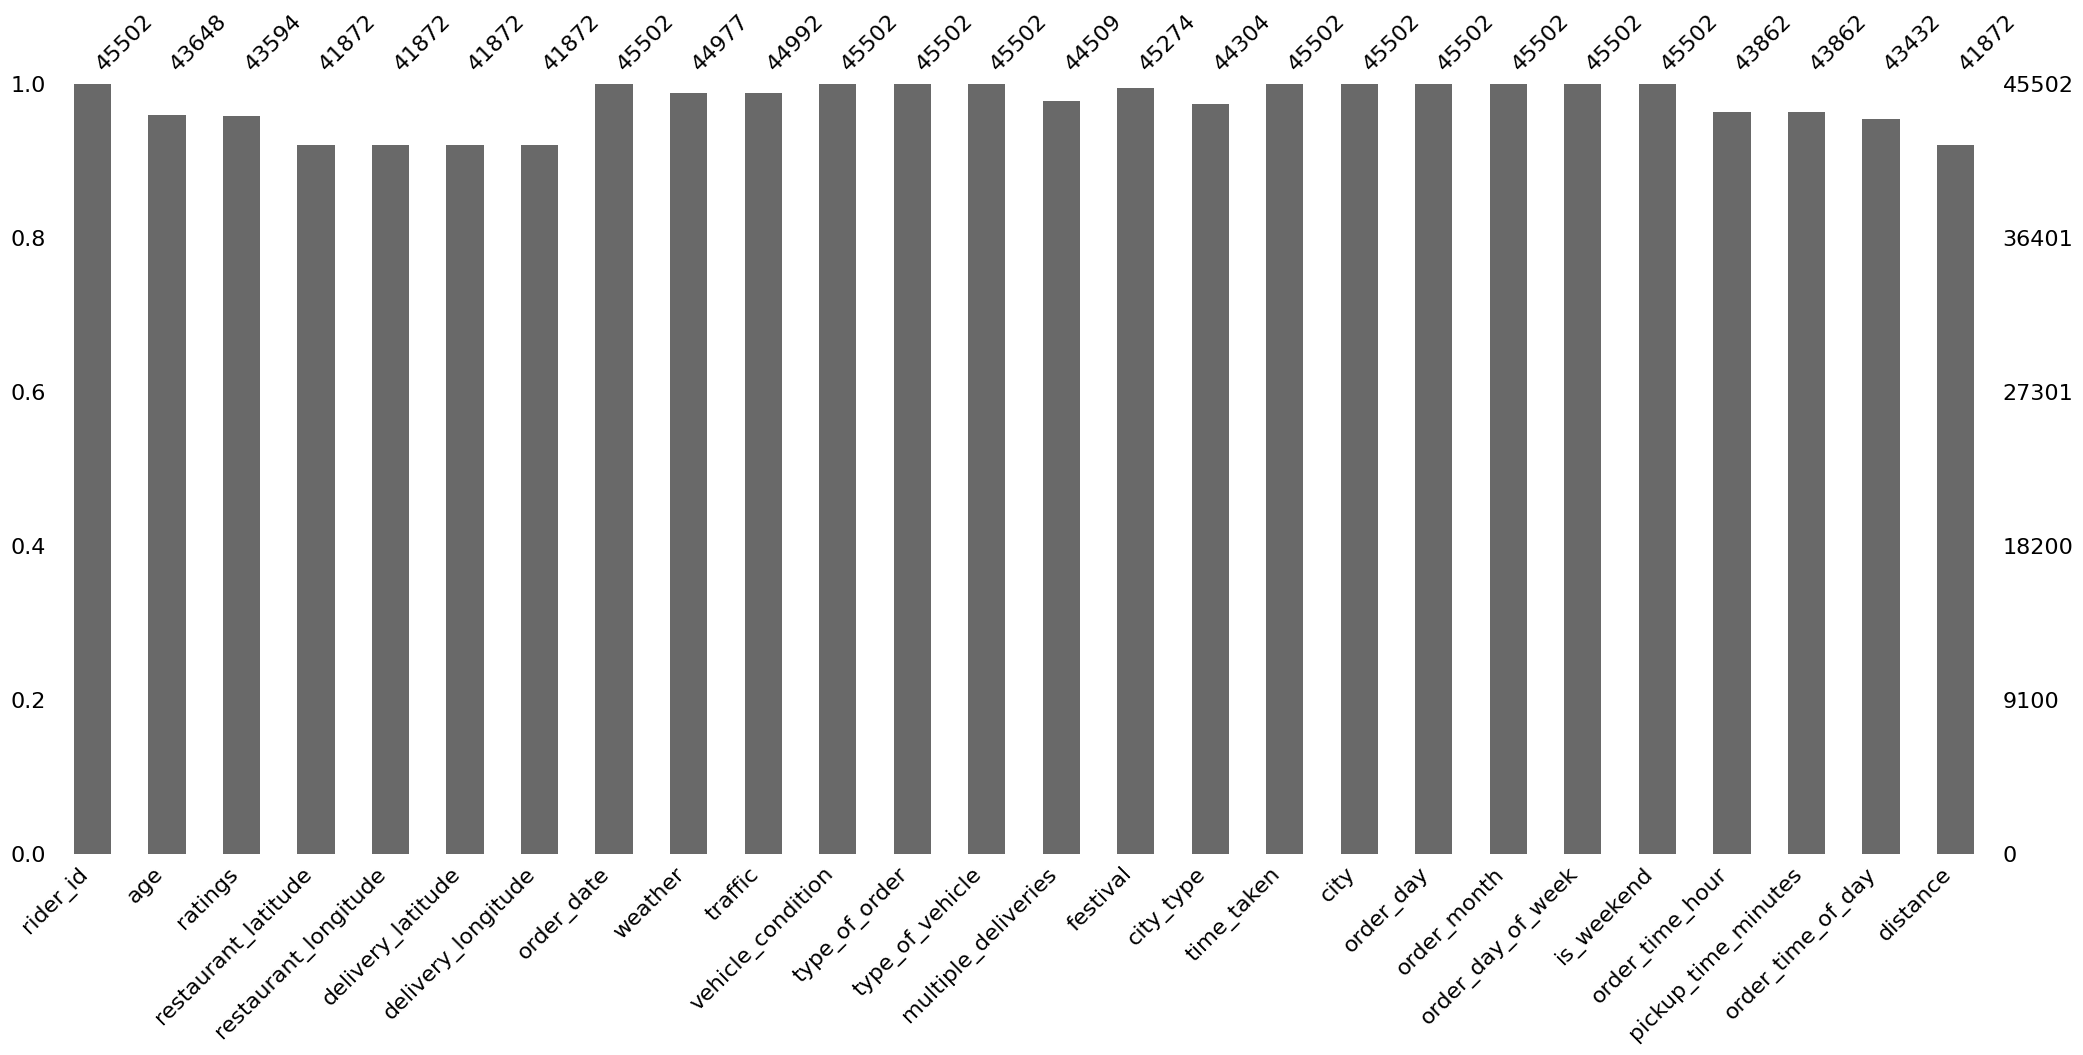

In [111]:
msno.bar(df)

<Axes: >

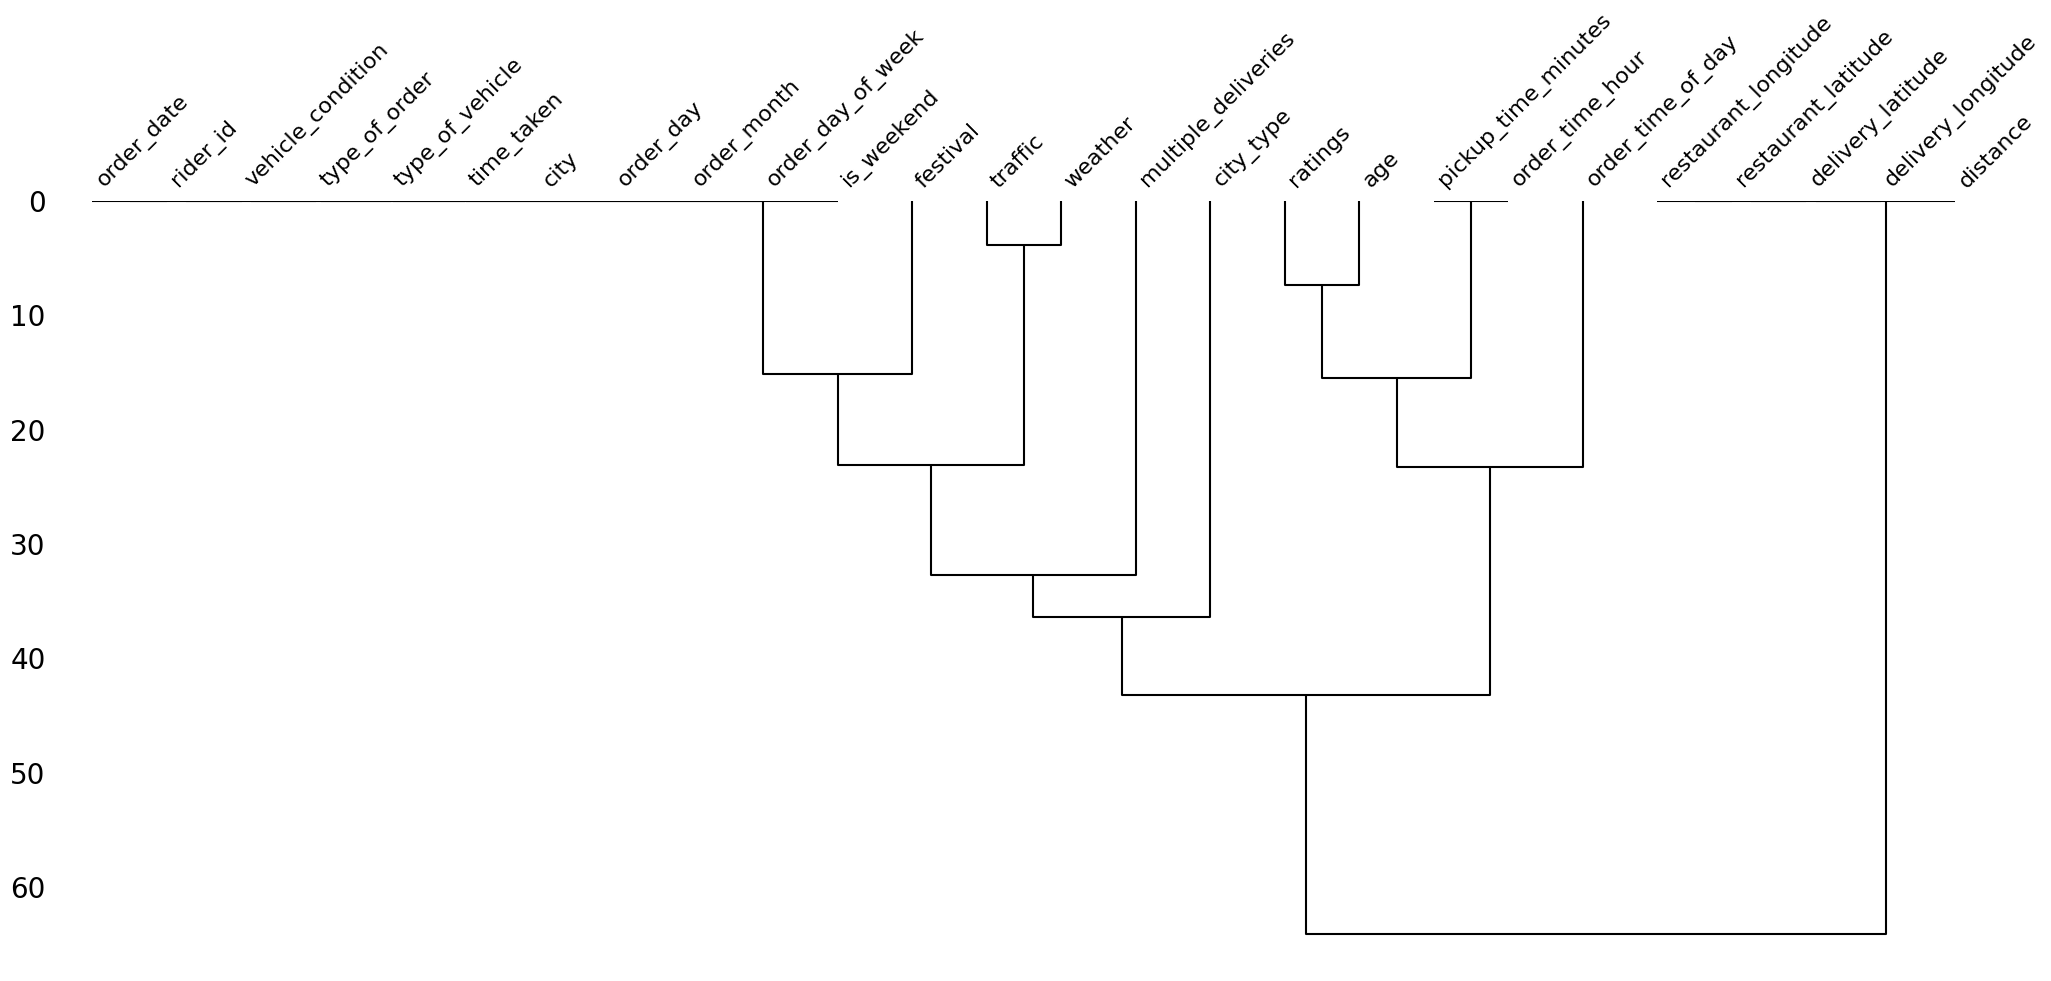

In [112]:
msno.dendrogram(df)

# Functions To Perform Analysis

In [113]:
def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15,10))
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name,hue=cat_col, ax=ax1)
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name,hue=cat_col, ax=ax2)
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name,bins=bins,hue=cat_col,kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])
    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        })
    )
    print("*" * 50)
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1,
                  y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()

def chi_2_test(dataframe, col1, col2, alpha= 0.05):
    data = (
        dataframe.loc[:, [col1, col2]]
        .dropna()
    )
    # create contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # perform chi-squared test
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant association between {col1} and {col2}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant association between {col1} and {col2}.")

def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    data = (
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_group]
    f_stat, p_val = f_oneway(*groups)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant relationship between {num_col} and {cat_col}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant relationship between {num_col} and {cat_col}.")

def test_for_normality(dataframe, column_name, alpha=0.05):
    data = dataframe[column_name]
    print("Jarque Bera Test for Normality")
    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis. The data is normally distributed.",end="\n\n")

# Time Taken -> Target Column

In [114]:
df['time_taken'].dtype

dtype('int64')

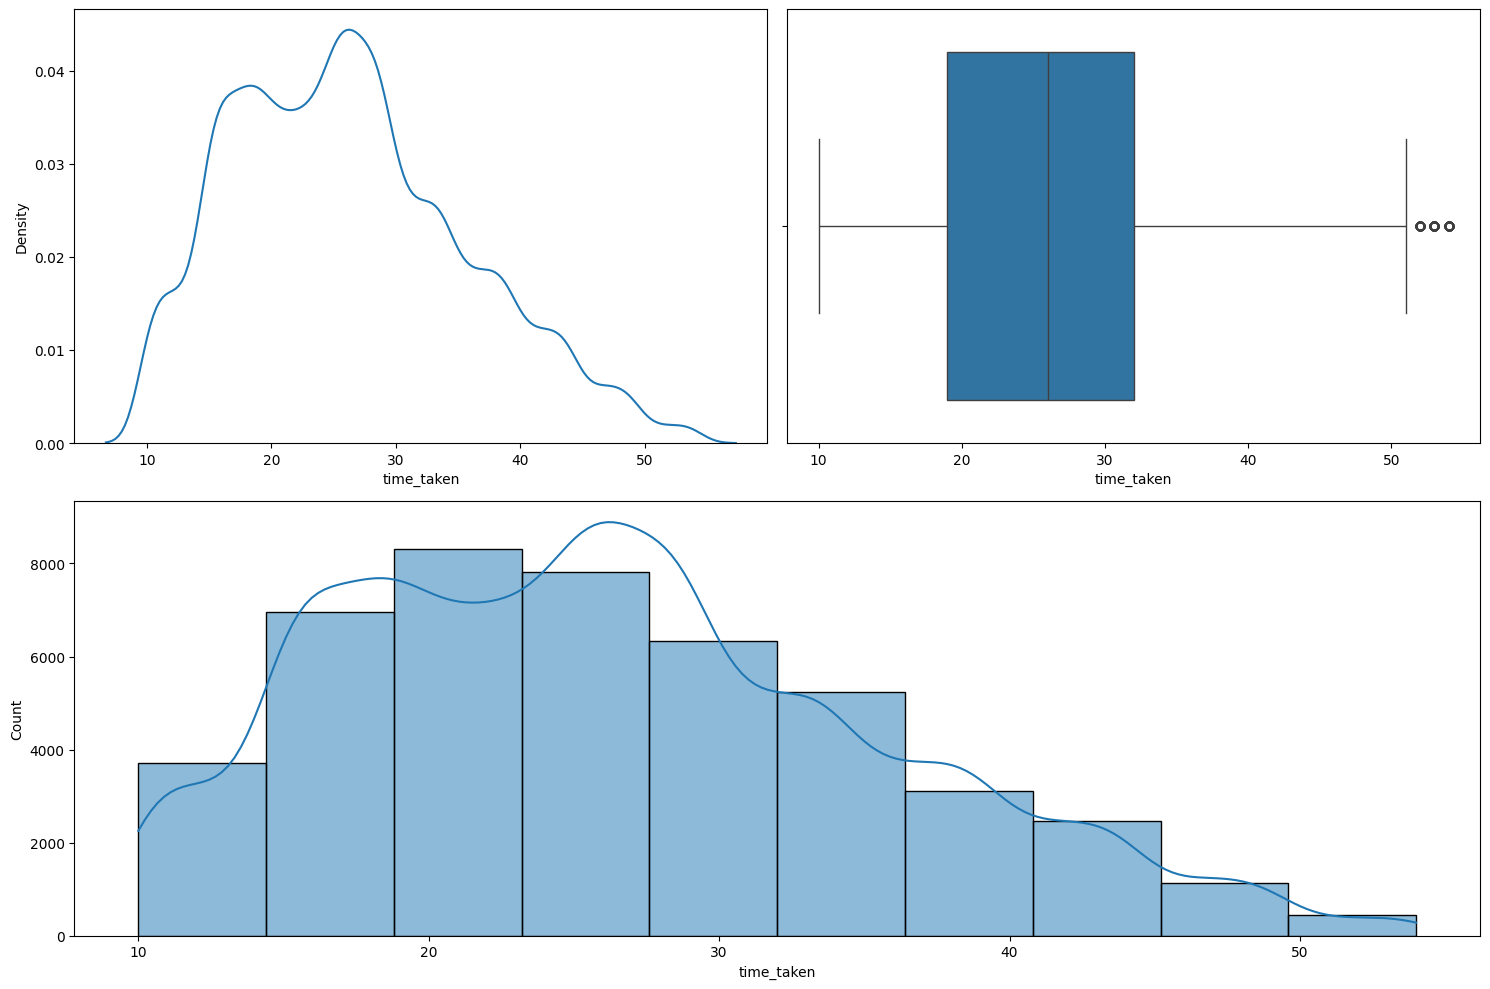

In [115]:
numerical_analysis(df, 'time_taken',bins=10)

**Observations**:

1. The target column is not fully continuous in nature.
2. The target column shows dual modality with two peaks- One peak around the 17-18 mark and other around 26-27 mark.
4. The target column has some extreme points which can be thought of as outliers but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

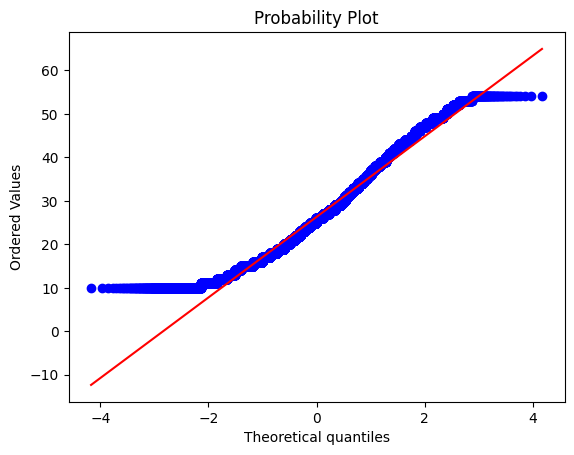

In [116]:
# plot QQ plot for the target

probplot(df['time_taken'], plot=plt)
plt.show()

In [117]:
test_for_normality(df, 'time_taken')

Jarque Bera Test for Normality
0.0
Reject the null hypothesis. The data is not normally distributed.


__Outlier Analysis of Target Column.__

In [118]:
# check out the rows where data is acting as outlier

target_25_per, target_75_per = np.percentile(df['time_taken'], [25, 75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df.loc[(df['time_taken'] > upper_bound),"traffic"].value_counts()

traffic
jam     241
high     24
Name: count, dtype: int64

In [119]:
df.loc[(df['time_taken'] > upper_bound),"weather"].value_counts()

weather
fog           57
sunny         51
windy         44
cloudy        44
stormy        37
sandstorms    32
Name: count, dtype: int64

In [120]:
# average distances
avg_distance = df.loc[:,"distance"].mean()
avg_distance_extreme = df.loc[(df['time_taken'] > upper_bound),"distance"].mean()

print(avg_distance, avg_distance_extreme)

9.71929632319958 13.29215081388658


__Observations on Outliers__

1. Time taken is more when the traffic condition was 'Jam' and 'High
2. Time taken is more when the distances were more.

__Hence the Outlier in the target column are not actually the Outliers , they are just extreme events. Hence I'll not remove Outliers.__

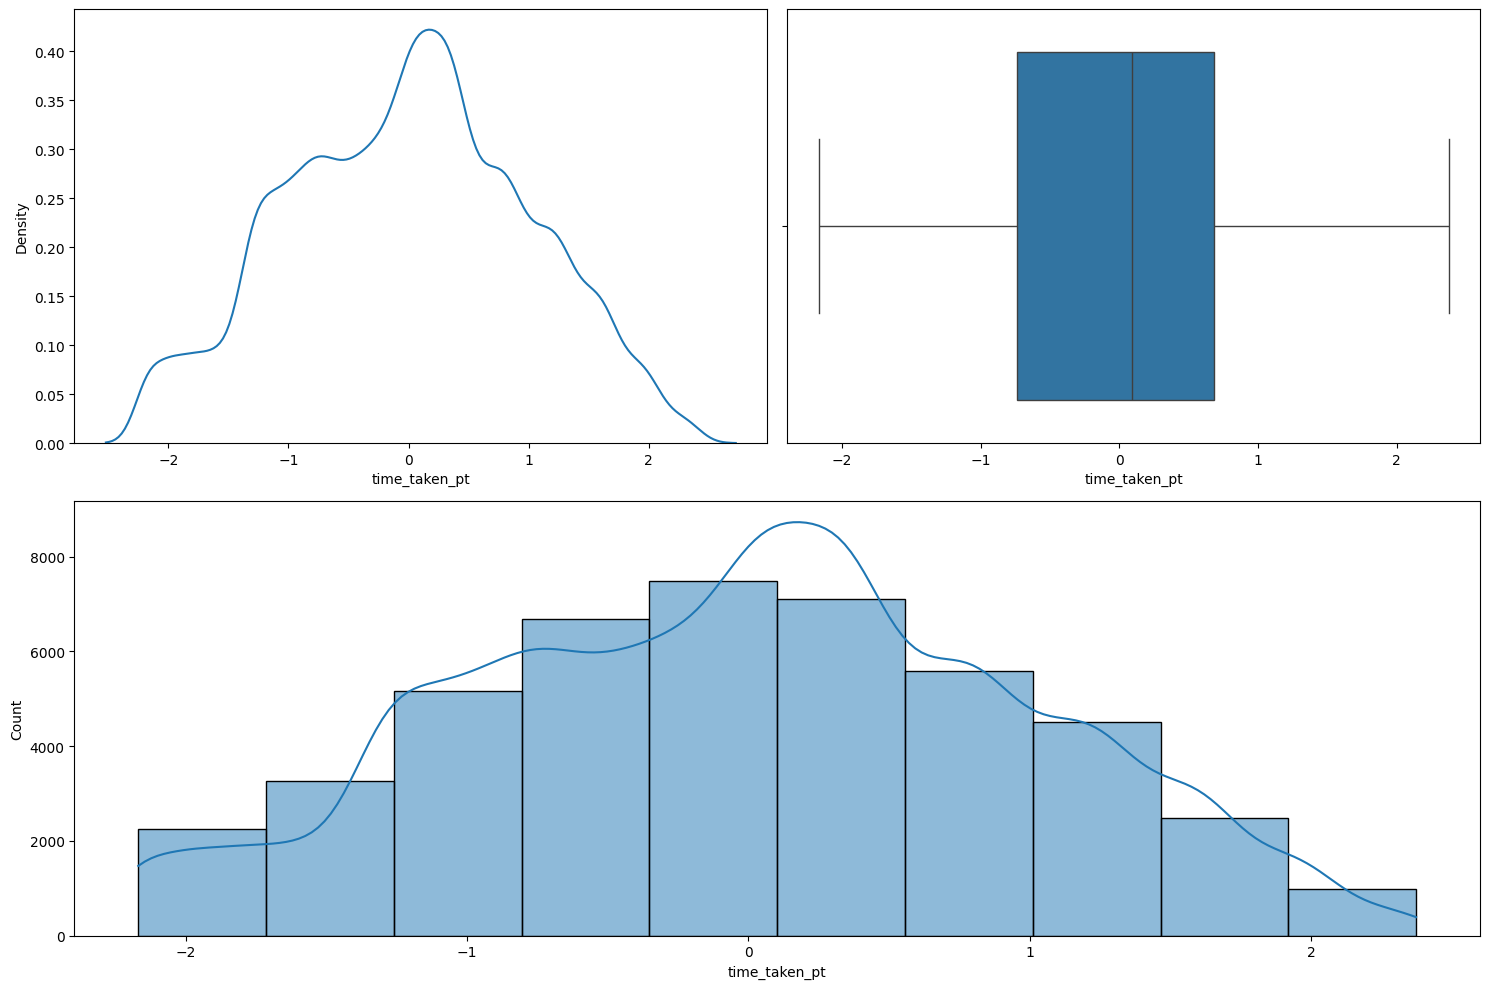

In [121]:
# fix traget column using transformation

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df['time_taken_pt'] = pt.fit_transform(df[['time_taken']])

numerical_analysis(df, "time_taken_pt", bins=10)

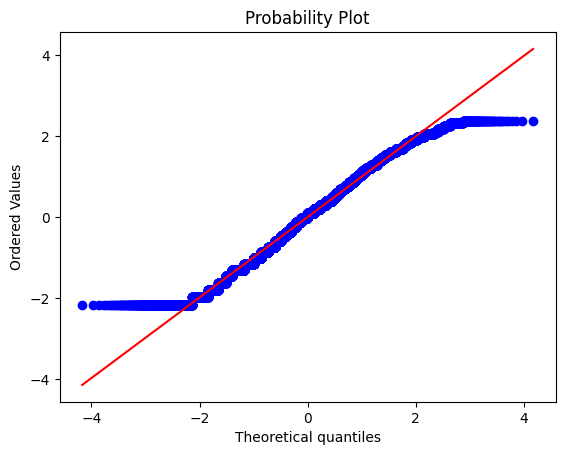

In [122]:
# plot QQ plot for the target after transformation

probplot(df['time_taken_pt'], plot=plt)
plt.show()

# Rider ID

__Still Keeping this column because I may use this column to impute age and ratings. Not Sure but the analysis will tell.__

In [123]:
df['rider_id'].dtype

dtype('O')

In [124]:
df[["rider_id","age","ratings"]]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [125]:
rider_id_group = df[["rider_id","age","ratings"]].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [126]:
df[["rider_id","age","ratings"]].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [127]:
(
    df
    .loc[(df[["rider_id","age","ratings"]].duplicated(keep=False)),["rider_id","age","ratings"]]
    .dropna()
    .sort_values(["rider_id"])
)

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


__Not Useful for our analysis.__

# age

In [128]:
df['age'].dtype

dtype('float64')

In [129]:
df['age'].describe()

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

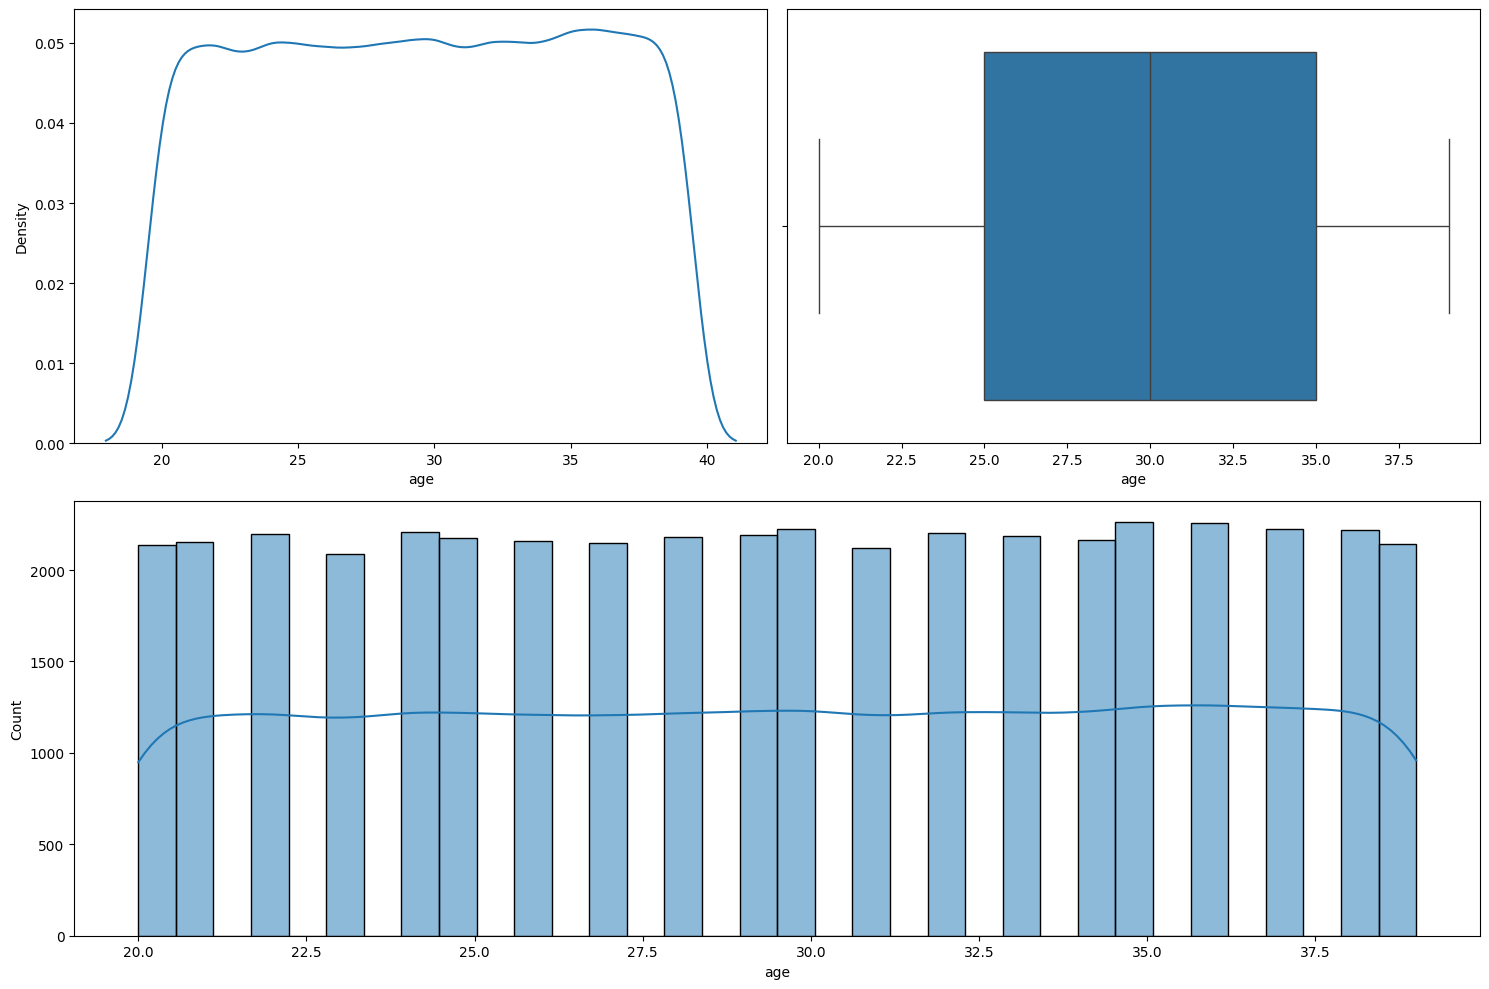

In [130]:
# numerical analysis for age

numerical_analysis(df, 'age')

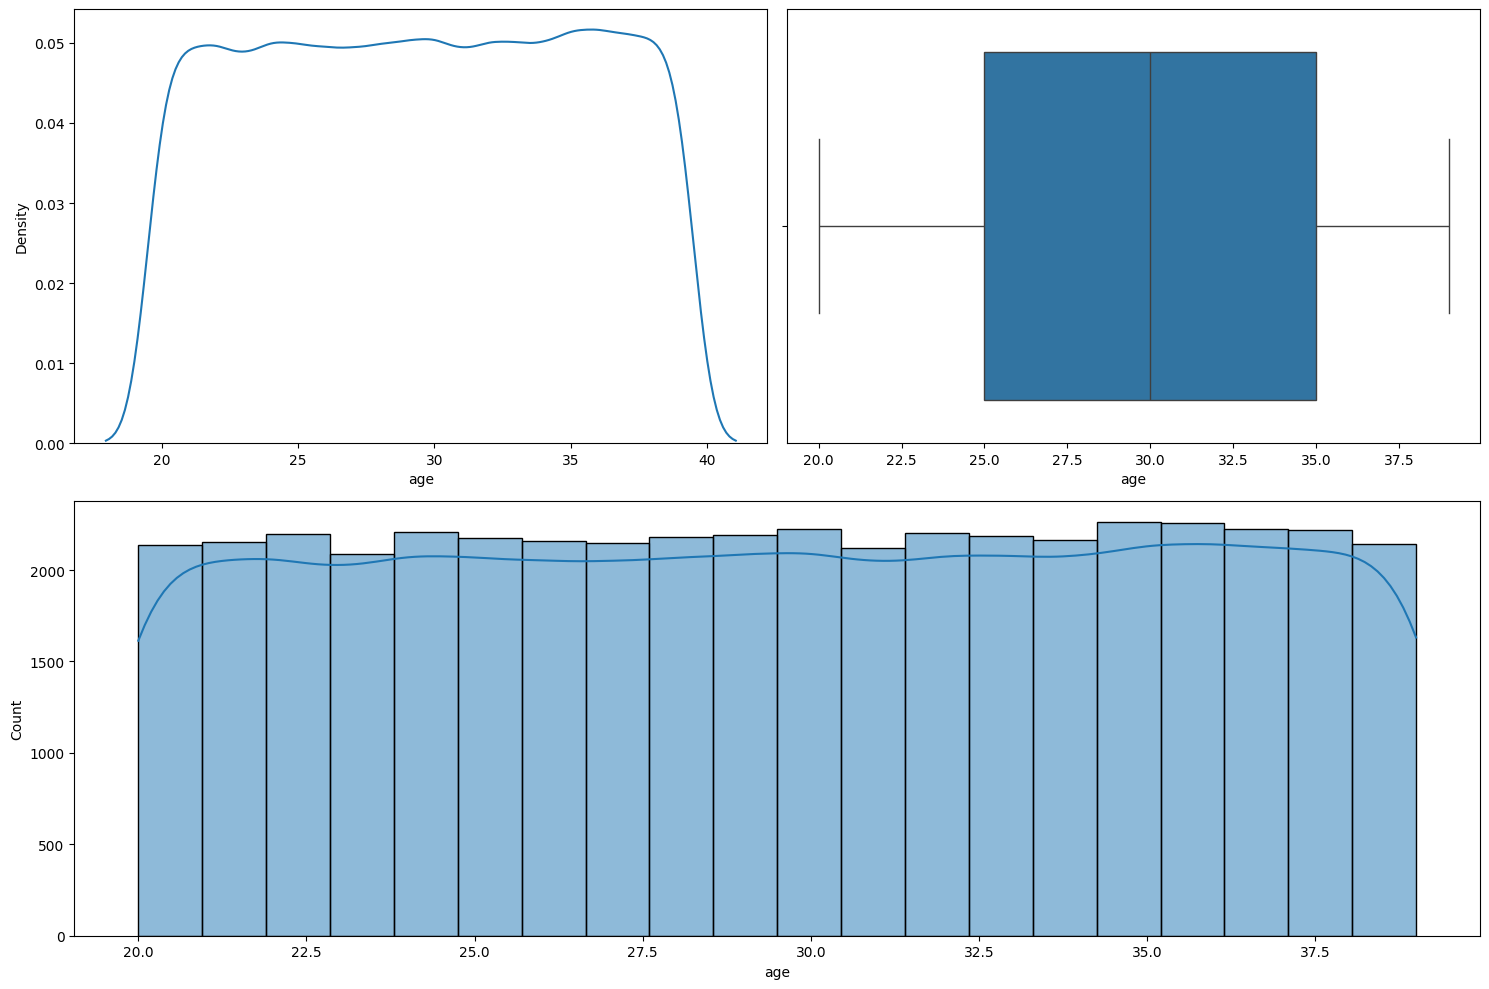

In [131]:
numerical_analysis(df, 'age',bins=20)

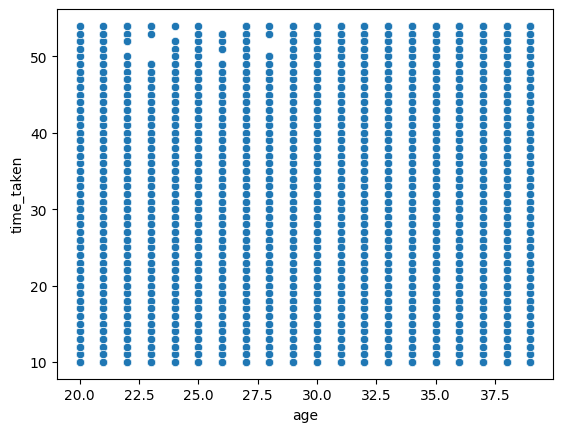

In [132]:
sns.scatterplot(data=df, x='age', y='time_taken')
plt.show()

__Age is a discrete column.__

**Age of the rider does not show any impact on timetaken to deliver**

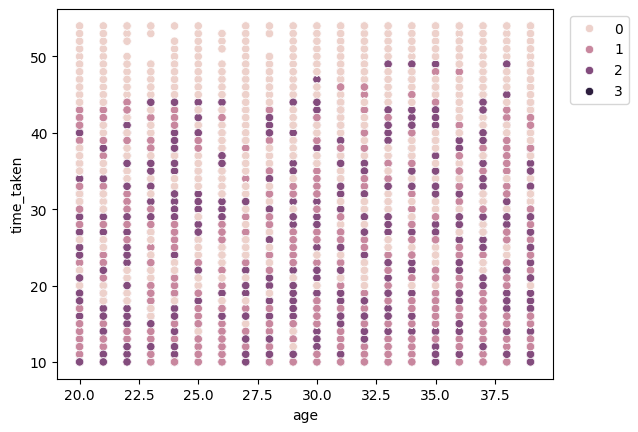

In [133]:
sns.scatterplot(data=df, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

<Axes: xlabel='type_of_vehicle', ylabel='age'>

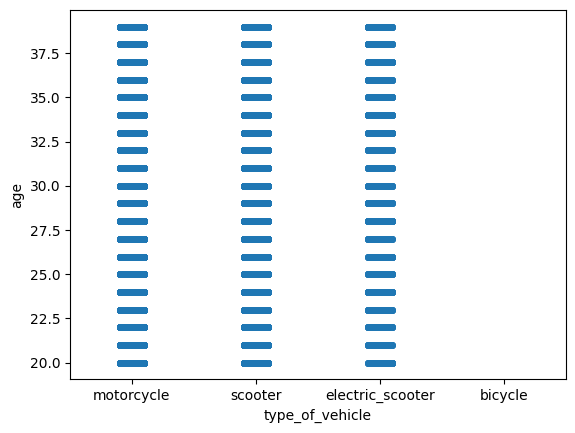

In [134]:
sns.stripplot(df,x='type_of_vehicle',y='age')

In [135]:
df.loc[df['type_of_vehicle'] == 'bicycle']['age'].isna().sum()

np.int64(53)

# Ratings

In [136]:
df['ratings'].dtype

dtype('float64')

In [137]:
df['ratings'].describe()

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

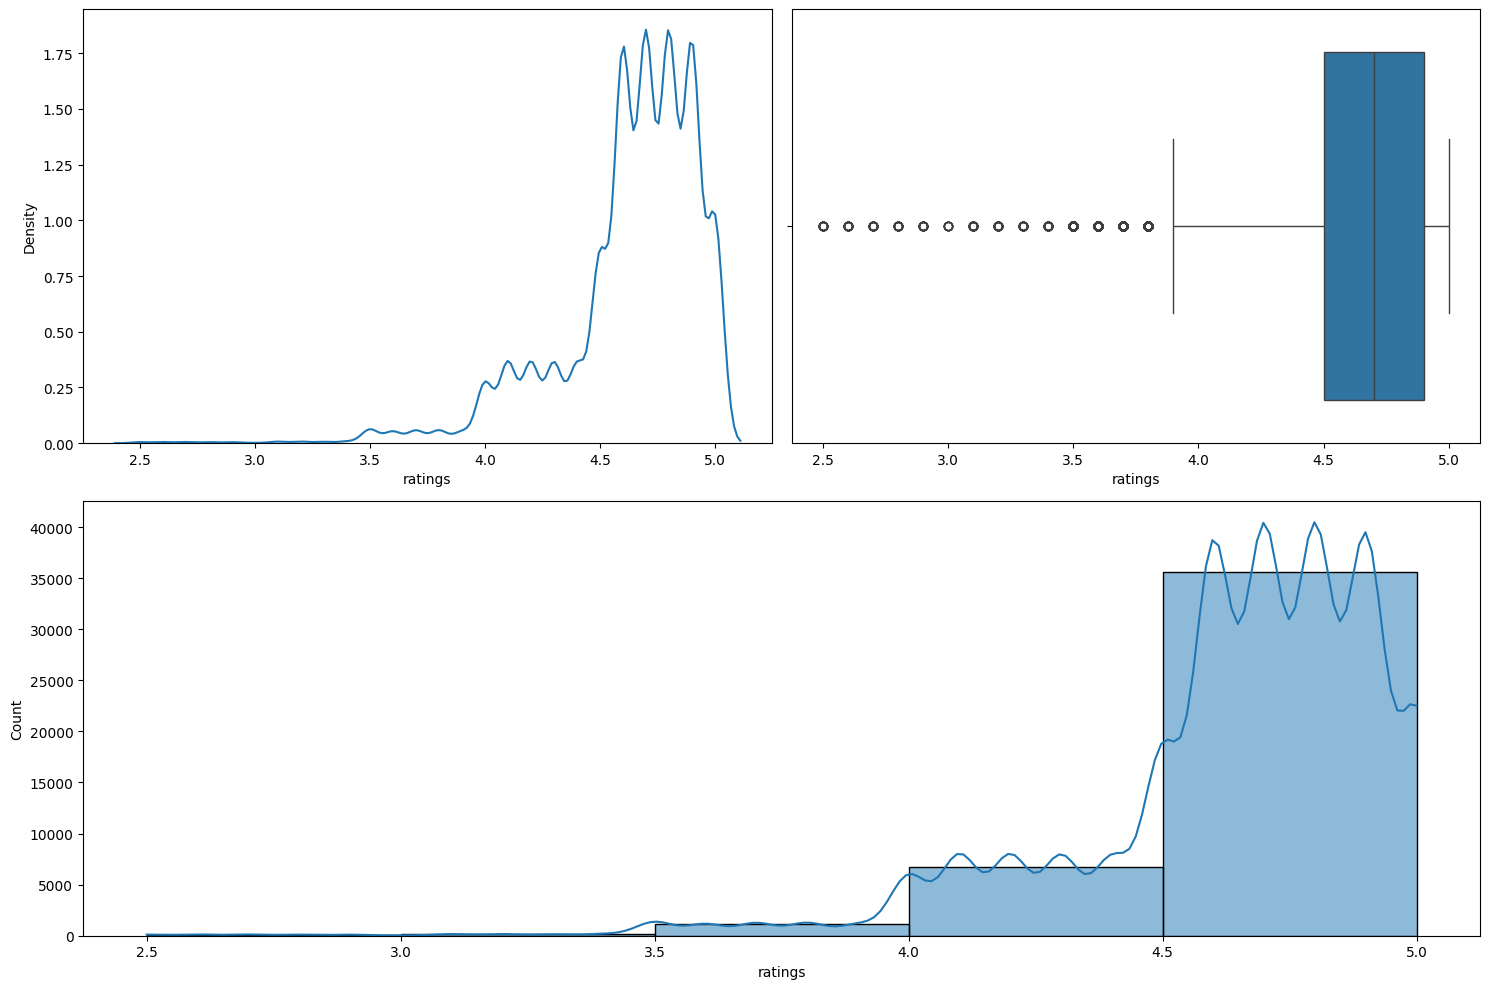

In [138]:
numerical_analysis(df, 'ratings',bins=5)

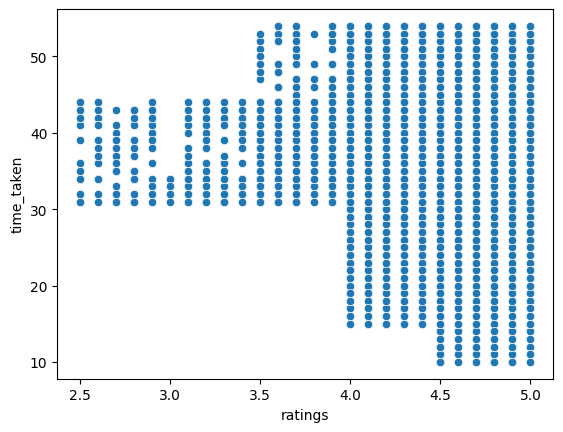

In [139]:
# does ratings affect delivery time

sns.scatterplot(data=df, x='ratings', y='time_taken')
plt.show()

__Observations__

**It seems like riders with more ratings get more orders**

**Higher ratings equates to more work and more income opportunities**



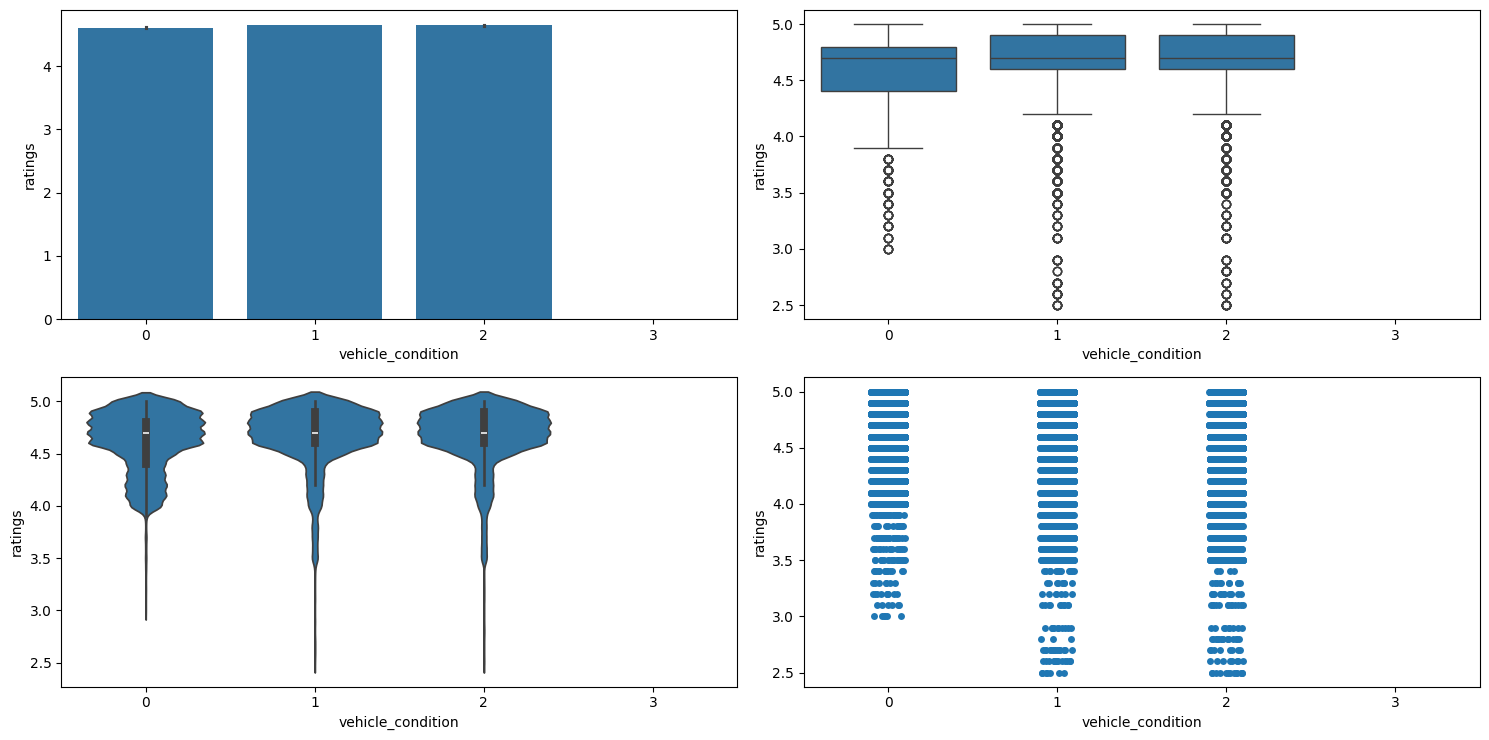

In [140]:
# does ratings get affected by vehicle type

numerical_categorical_analysis(df, 'vehicle_condition', 'ratings')

**Yes they do**

- The more worst the vehicle condition is, the more lower the rating gets.
- The category 3 has no data means there are NaN values. This simply means that customers avoid rating their riders even rating of 1 when the vehicle condition is bad.

In [141]:
(
    df[["ratings","vehicle_condition"]]
    .loc[df["vehicle_condition"]==3,"ratings"]
    .value_counts(dropna=False)
)

ratings
NaN    429
Name: count, dtype: int64

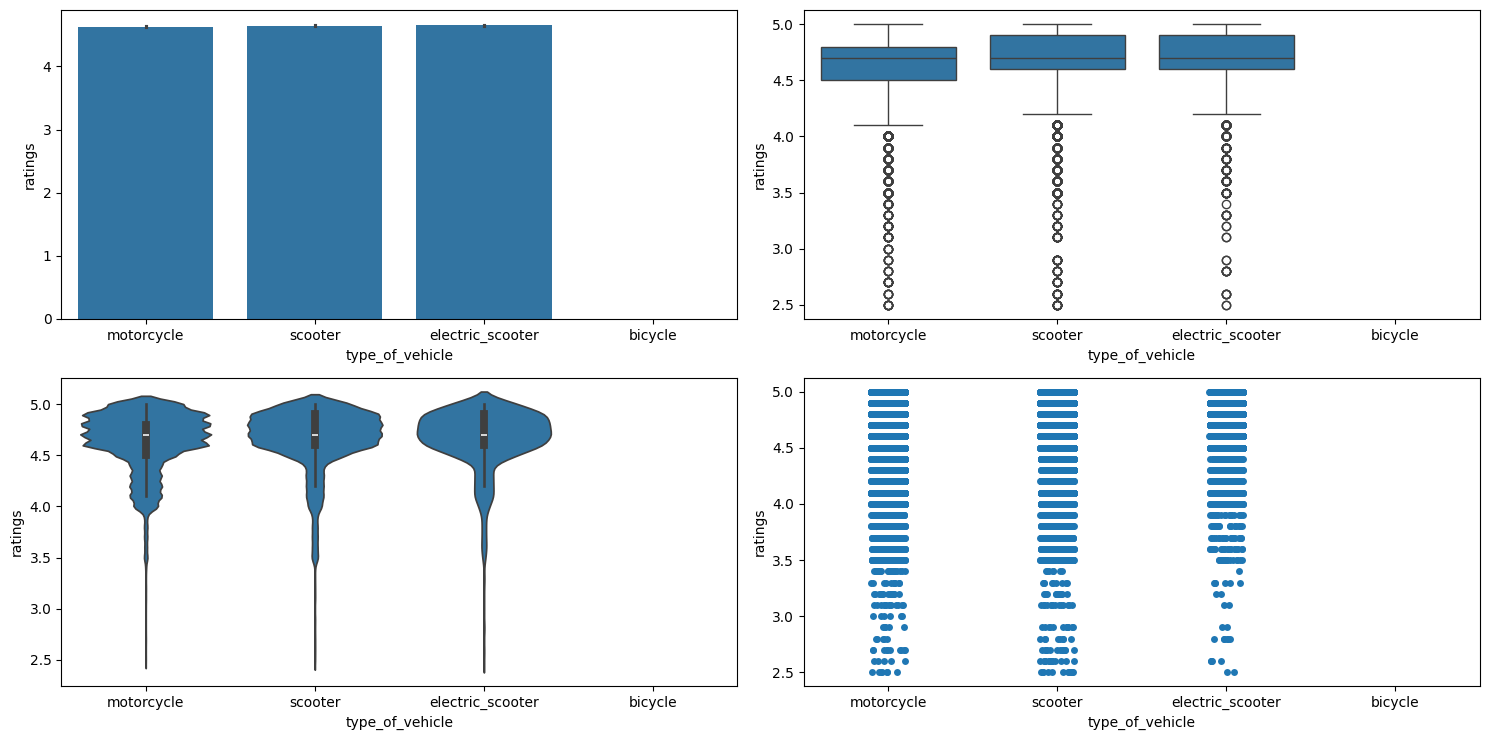

In [142]:
# does type of vehicle affects ratings

numerical_categorical_analysis(df, 'type_of_vehicle', 'ratings')

__Not So Much. Distribution is same across the vehicle categories.__

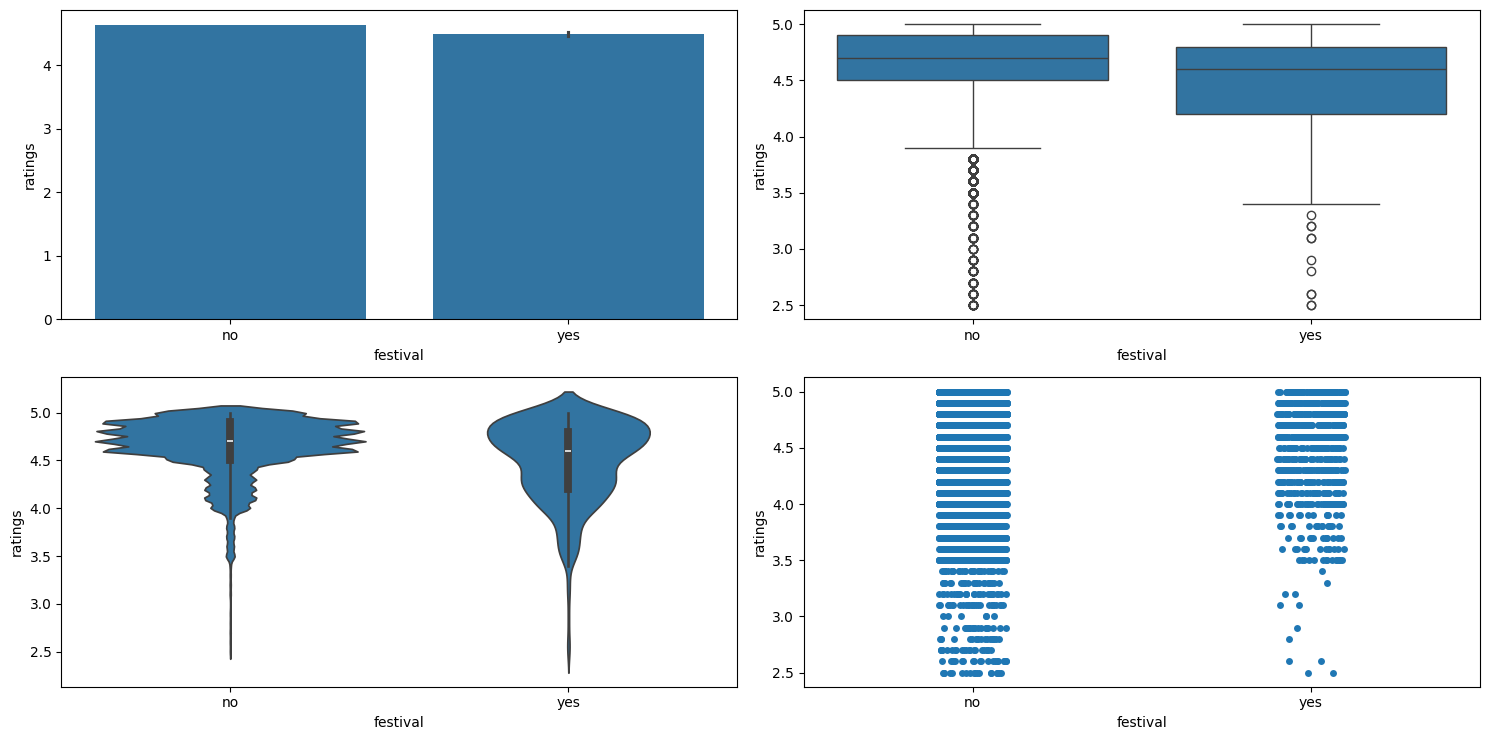

In [143]:
# festvals and rider ratings

numerical_categorical_analysis(df, 'festival', 'ratings')

__Not convincing enough. But I can say that whenever there is a festival riders usually do not get a lower rating.__

# Location Based Features

In [144]:
df.columns[3:7].tolist() + ["city"]

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city']

In [145]:
location_subset = df.loc[:,df.columns[3:7].tolist() + ["city"]]

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [146]:
location_subset.dtypes

restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
city                     object
dtype: object

In [147]:
# drop missing values

location_subset.dropna(inplace=True)

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [148]:
# plot deliveries on map

delivery_df = pd.DataFrame({
    'latitude': location_subset['delivery_latitude'],
    'longitude': location_subset['delivery_longitude'],
    "city_name": location_subset["city"]
})


# Create a map using Plotly's scatter_mapbox
fig = px.scatter_mapbox(
    delivery_df,
    lat='latitude',
    lon='longitude',
    title="Delivery Points",
    hover_name="city_name"
)

# Update the layout for the map of India
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 20.5937, "lon": 78.9629},  # Centered over India
    mapbox_zoom=3,
)

# Show the plot
fig.show()

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_11824\4033889213.py:11: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


__City Corresponds to Delivery Latitude and Longitude.__

# Order Date

In [149]:
df.filter(like="order")

,order_date,type_of_order,order_day,order_month,order_day_of_week,order_time_hour,order_time_of_day
0,2022-03-19,snack,19,3,Saturday,11.0,morning
1,2022-03-25,snack,25,3,Friday,19.0,evening
2,2022-03-19,drinks,19,3,Saturday,8.0,morning
3,2022-04-05,buffet,5,4,Tuesday,18.0,evening
4,2022-03-26,snack,26,3,Saturday,13.0,afternoon
...,...,...,...,...,...,...,...
45497,2022-03-24,meal,24,3,Thursday,11.0,morning
45498,2022-02-16,buffet,16,2,Wednesday,19.0,evening
45499,2022-03-11,drinks,11,3,Friday,23.0,night
45500,2022-03-07,snack,7,3,Monday,13.0,afternoon


In [150]:
# order date columns

order_date_subset = df.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]

order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,Saturday,1,no
1,2022-03-25,25,3,Friday,0,no
2,2022-03-19,19,3,Saturday,1,no
3,2022-04-05,5,4,Tuesday,0,no
4,2022-03-26,26,3,Saturday,1,no
...,...,...,...,...,...,...
45497,2022-03-24,24,3,Thursday,0,no
45498,2022-02-16,16,2,Wednesday,0,no
45499,2022-03-11,11,3,Friday,0,no
45500,2022-03-07,7,3,Monday,0,no


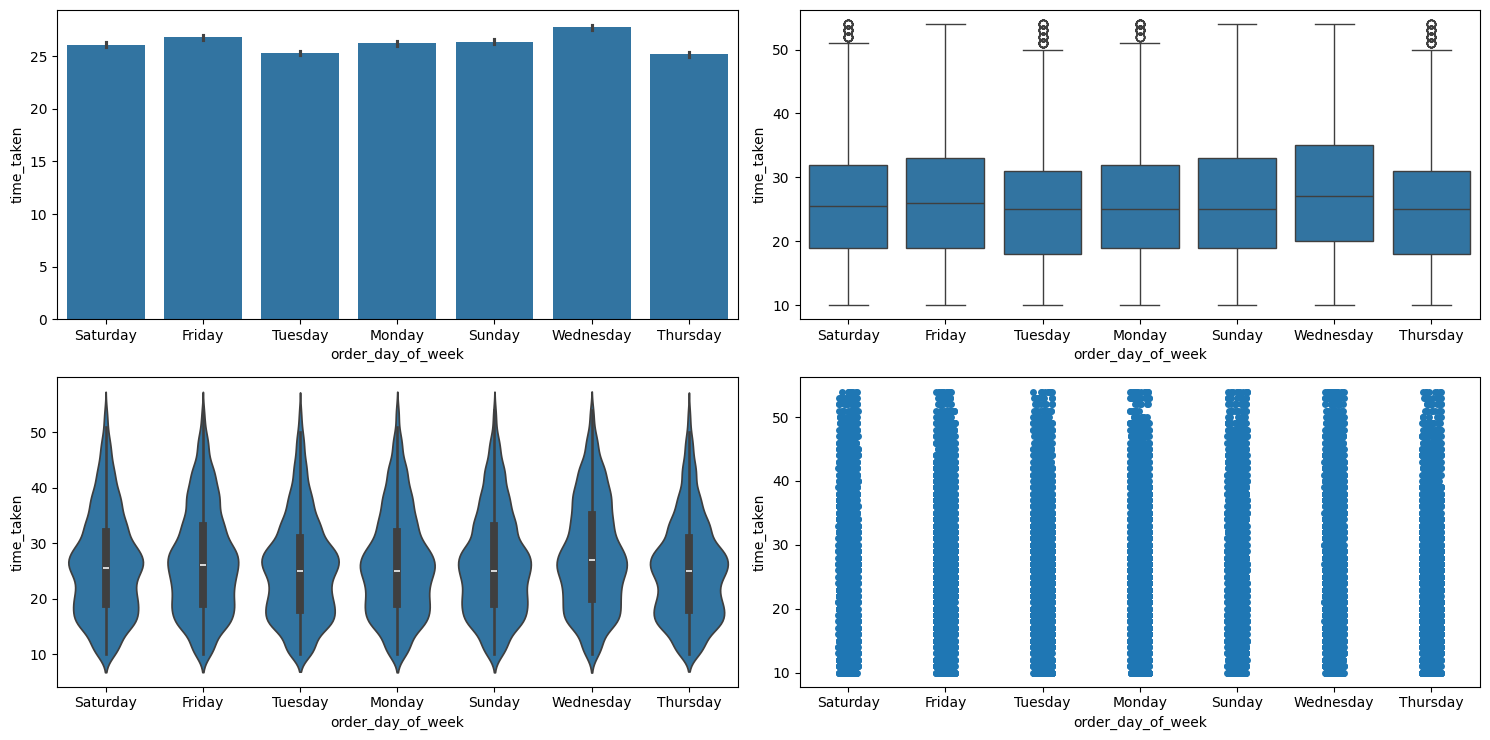

In [152]:
# analysis between day of week and target

numerical_categorical_analysis(df, "order_day_of_week", "time_taken")

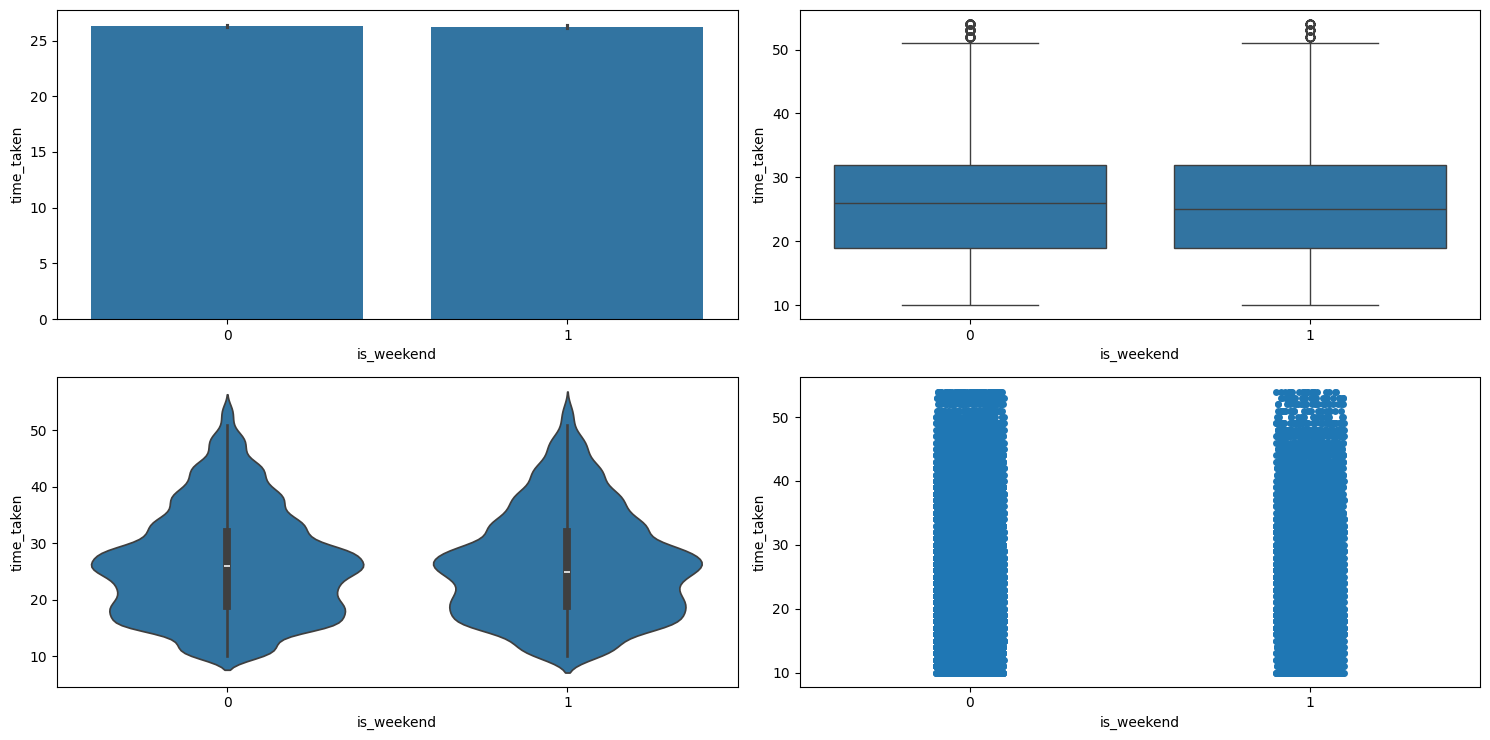

In [153]:
# does having a weekend affects target

numerical_categorical_analysis(df, "is_weekend", "time_taken")

In [154]:
# do weekends have an impact on traffic

chi_2_test(df, "is_weekend", "traffic")

0.6845961396354259
Fail to reject the null hypothesis. There is no significant association between is_weekend and traffic.


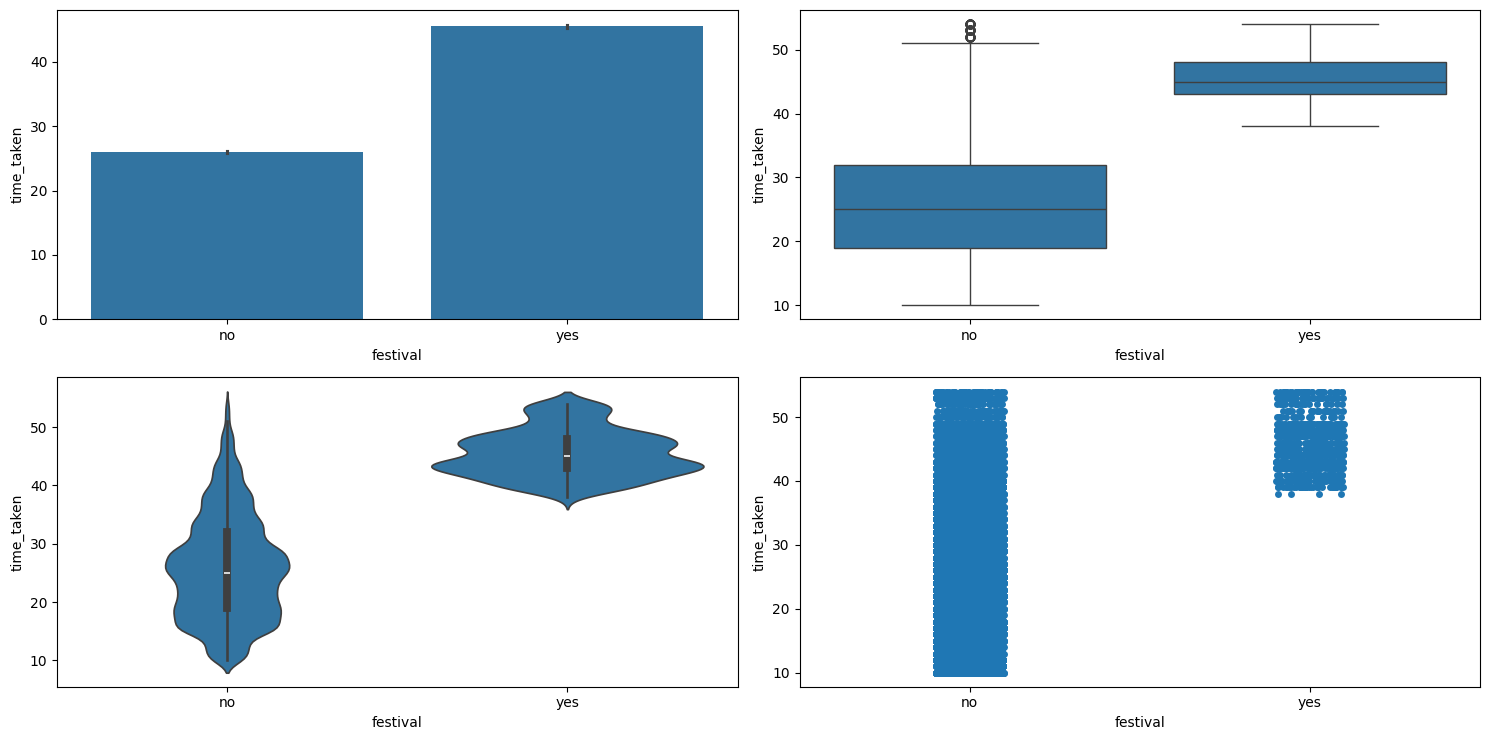

In [155]:
# festivals and target analysis

numerical_categorical_analysis(df, "festival", "time_taken")

**Observations**:
1. The avg time it takes for delivery varies when there is a festival.
2. The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer.

In [156]:
# do festival affect traffic

chi_2_test(df, "festival", "traffic")

1.1223471129146869e-153
Reject the null hypothesis. There is a significant association between festival and traffic.


__Festival does affect traffic.__

In [158]:
df.pivot_table(index='traffic',columns='festival',values="time_taken",aggfunc="mean")

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


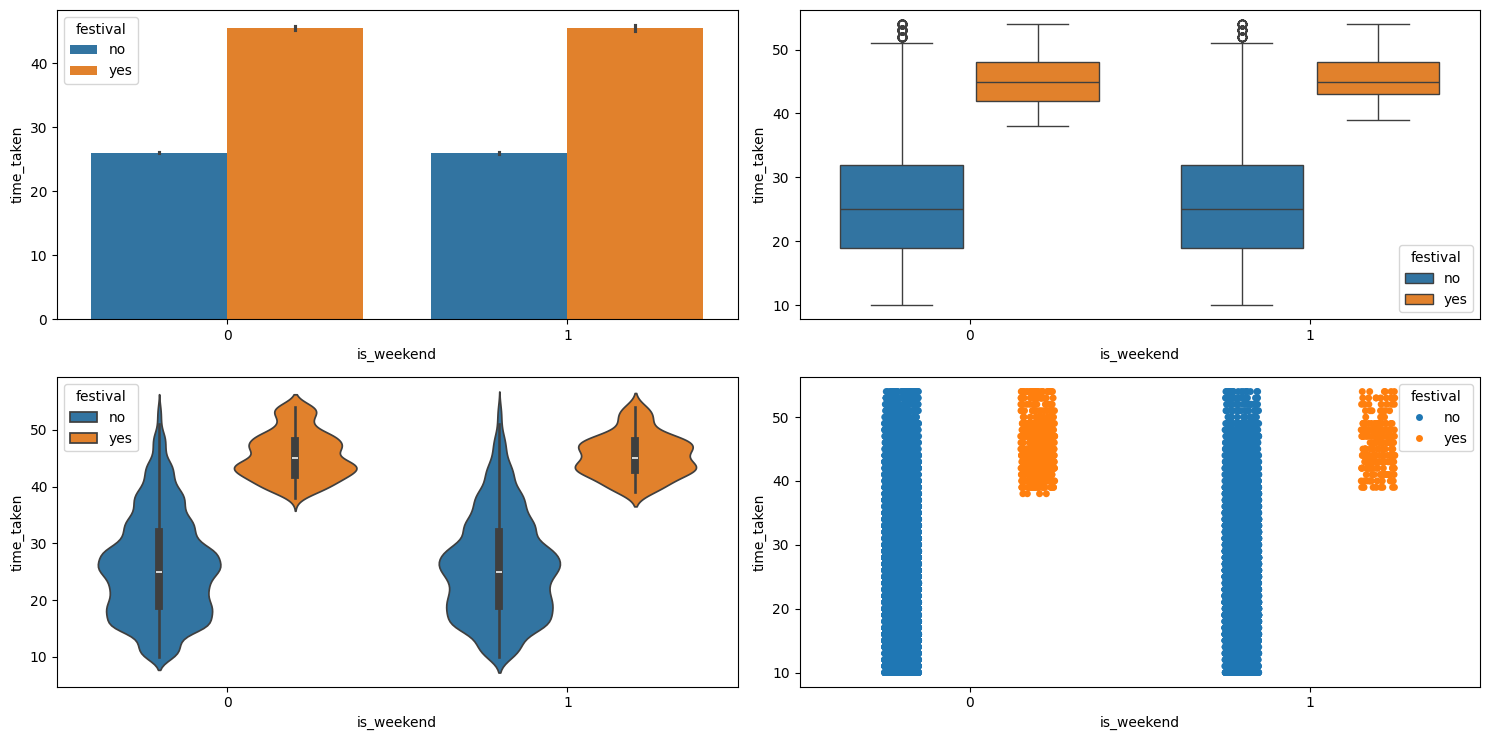

In [159]:
# does a weekend and a festival combined have an effect on delivery times

multivariate_analysis(df, "time_taken", "is_weekend", "festival")

__It does'nt matter , if we have festivals it takes longer than usual for deliveries due to traffic congestion.__

# Order Time

In [160]:
# time related columns

time_subset = df.loc[:,["order_time_hour","order_time_of_day","pickup_time_minutes"]]

time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


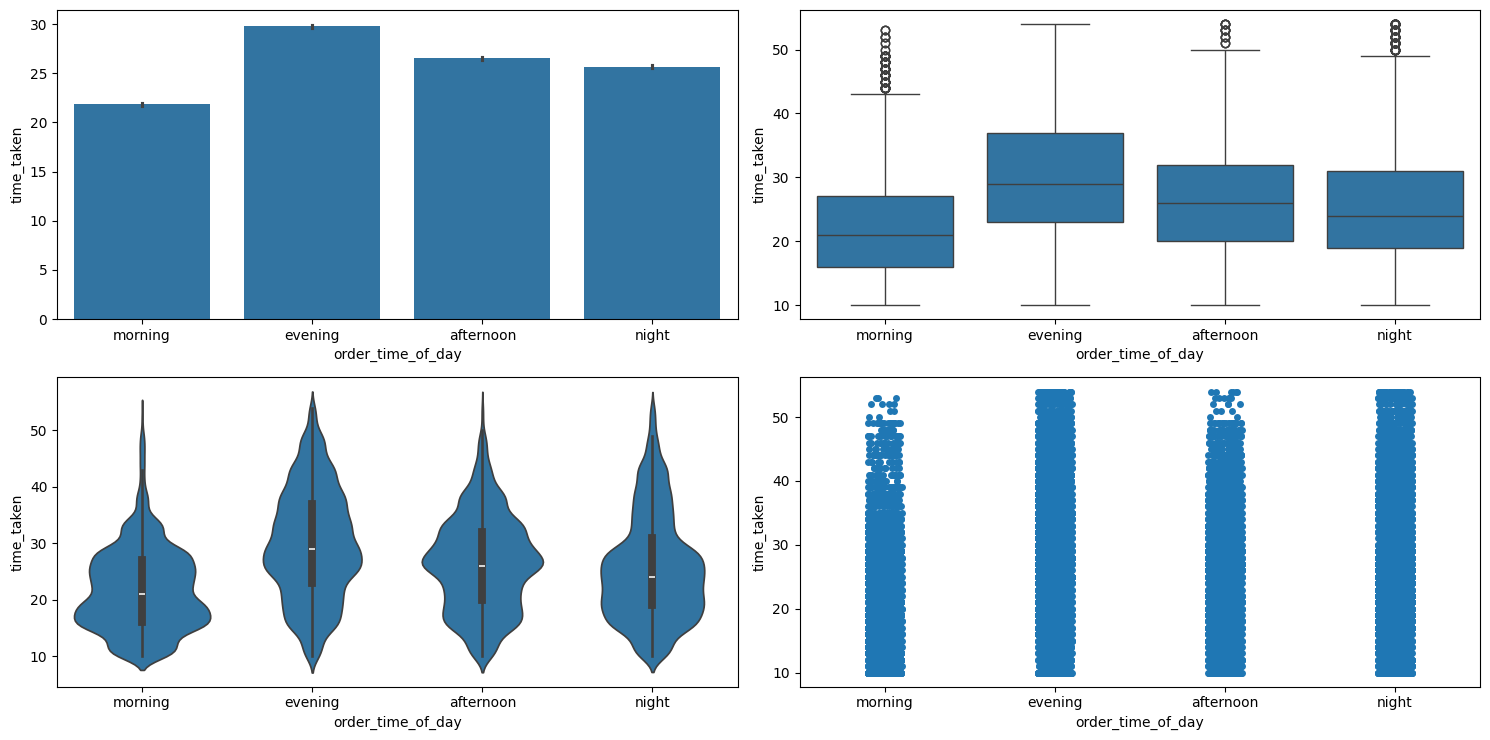

In [161]:
numerical_categorical_analysis(df, "order_time_of_day", "time_taken")

In [162]:
# relationship between time of day and traffic

chi_2_test(df, "order_time_of_day", "traffic")

0.0
Reject the null hypothesis. There is a significant association between order_time_of_day and traffic.


__Evening Orders takes time because of the traffic conditions and similarly it is highly dependent on traffic.__

In [163]:
# anova test

anova_test(df, "time_taken", "order_time_of_day")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and order_time_of_day.


In [164]:
# Top 5 times(hrs) of the day in which customers  order the most

df["order_time_hour"].value_counts().head(5)

order_time_hour
21.0    4686
19.0    4595
22.0    4576
20.0    4539
23.0    4511
Name: count, dtype: int64

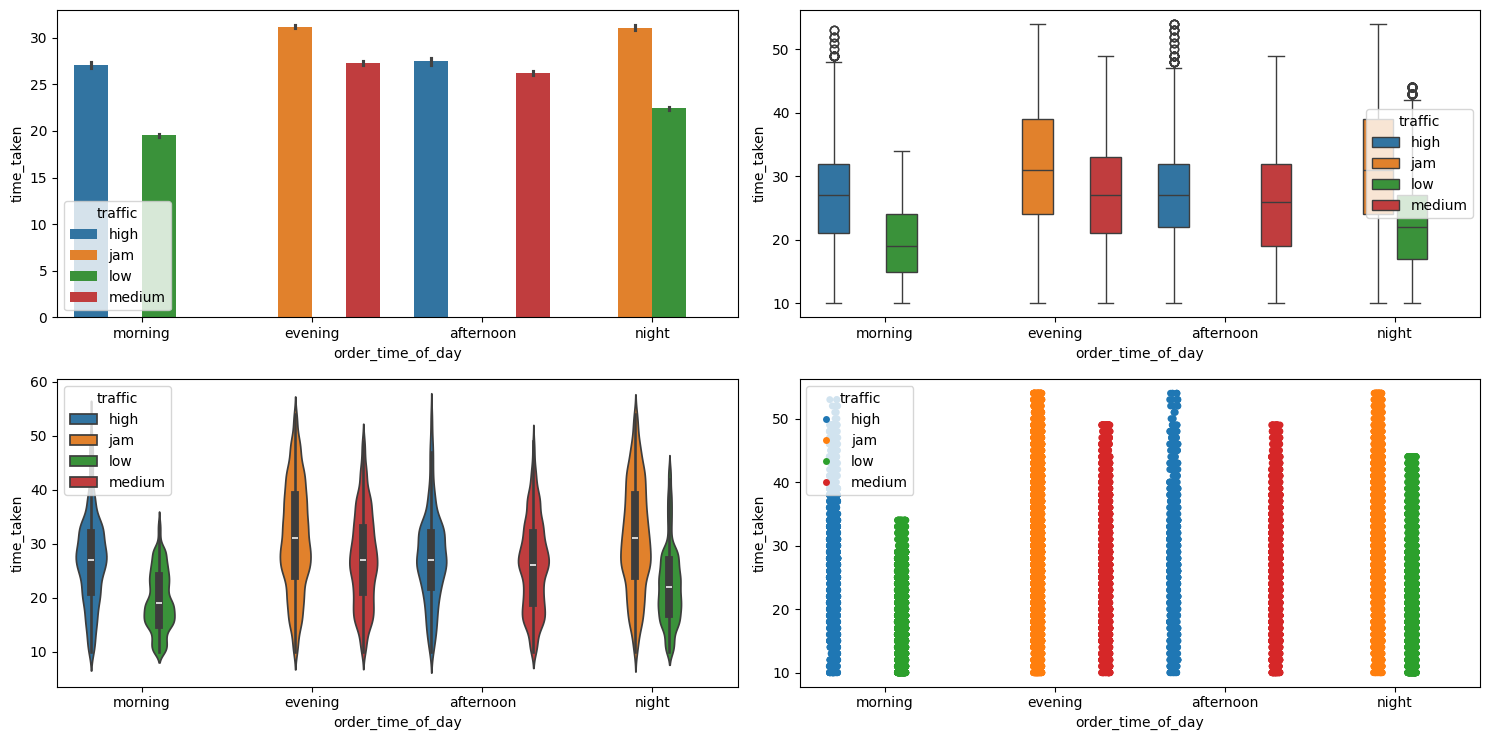

In [165]:
# can delivery time be affected by both time of day and traffic

multivariate_analysis(df, "time_taken", "order_time_of_day", "traffic")

,Count,Percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


**************************************************
The unique categories in order_time_hour column are [11.0, 19.0, 8.0, 18.0, 13.0, 21.0, 17.0, 20.0, 14.0, 9.0, 22.0, 12.0, 23.0, nan, 10.0, 16.0, 15.0, 0.0]
**************************************************
The number of categories in order_time_hour column are 17


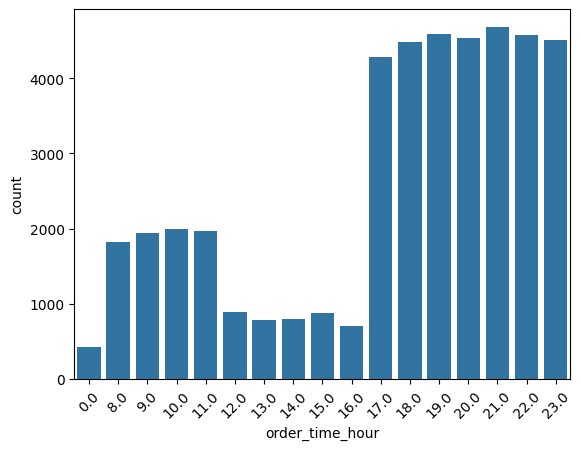

In [166]:
# categorical analysis on order_time_hour

categorical_analysis(df, "order_time_hour")

,Count,Percentage
order_time_of_day,,
night,13773,31.71%
evening,13614,31.35%
morning,8610,19.82%
afternoon,7435,17.12%


**************************************************
The unique categories in order_time_of_day column are ['morning', 'evening', 'afternoon', 'night', nan]
**************************************************
The number of categories in order_time_of_day column are 4


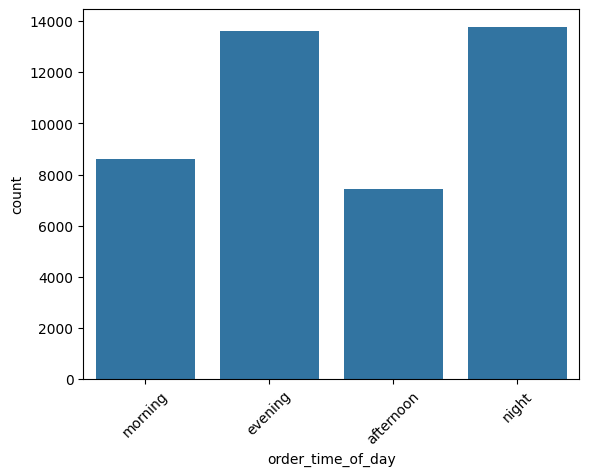

In [167]:
# categorical analysis on time of day

categorical_analysis(df, "order_time_of_day")

# Pickup Time

In [168]:
df['pickup_time_minutes'].dtype

dtype('float64')

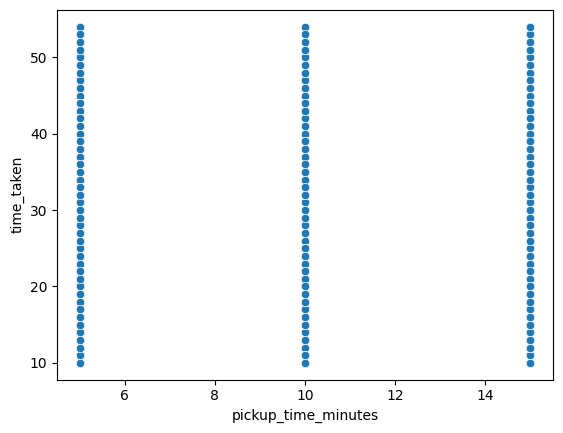

In [169]:
# relationship between pickup time and delivery time

sns.scatterplot(df,x="pickup_time_minutes",y="time_taken")
plt.show()

,Count,Percentage
pickup_time_minutes,,
5.0,14703,33.52%
15.0,14610,33.31%
10.0,14549,33.17%


**************************************************
The unique categories in pickup_time_minutes column are [15.0, 5.0, 10.0, nan]
**************************************************
The number of categories in pickup_time_minutes column are 3


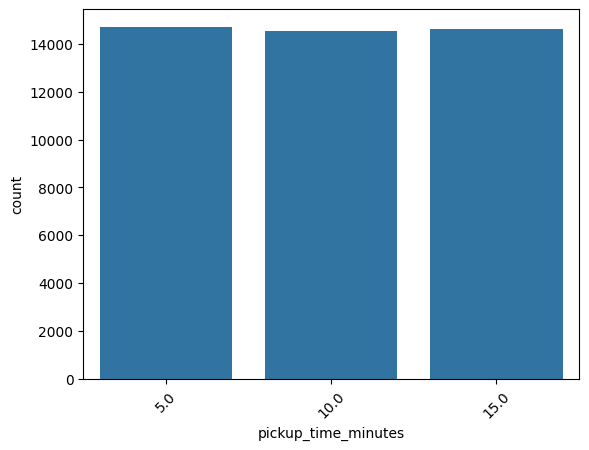

In [171]:

categorical_analysis(df, "pickup_time_minutes")

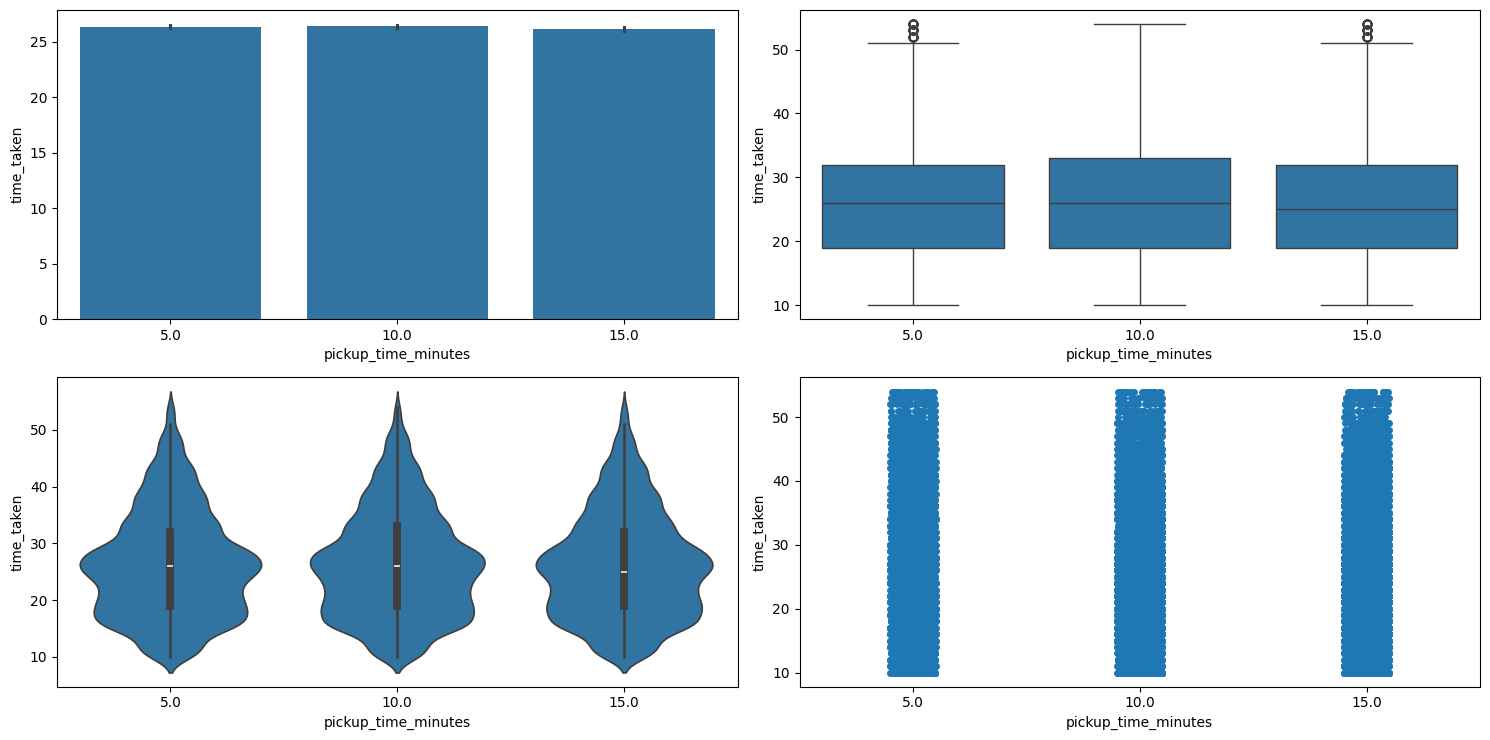

In [172]:
numerical_categorical_analysis(df, "pickup_time_minutes", "time_taken")

In [173]:
anova_test(df, "time_taken", "pickup_time_minutes")

0.09932647028819414
Fail to reject the null hypothesis. There is no significant relationship between time_taken and pickup_time_minutes.


__I can drop this column. As it is not having any signifacnt effect.__

# Traffic -> Imp

In [175]:
df['traffic'].dtype

dtype('O')

,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
The unique categories in traffic column are ['high', 'jam', 'low', 'medium', nan]
**************************************************
The number of categories in traffic column are 4


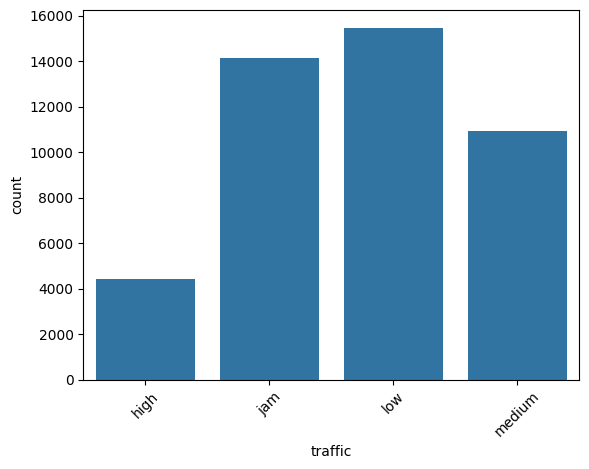

In [176]:
categorical_analysis(df, "traffic")

In [177]:
# does traffic depends on type of city

chi_2_test(df, "traffic", "city_type")

2.3390790568495405e-104
Reject the null hypothesis. There is a significant association between traffic and city_type.


In [179]:
# does traffic depends on city

chi_2_test(df, "traffic", "city")

0.4978080180955253
Fail to reject the null hypothesis. There is no significant association between traffic and city.


__From the statistical test I can conclude that traffic is dependent on city type (Metropolitan,urban,semi-urban).__

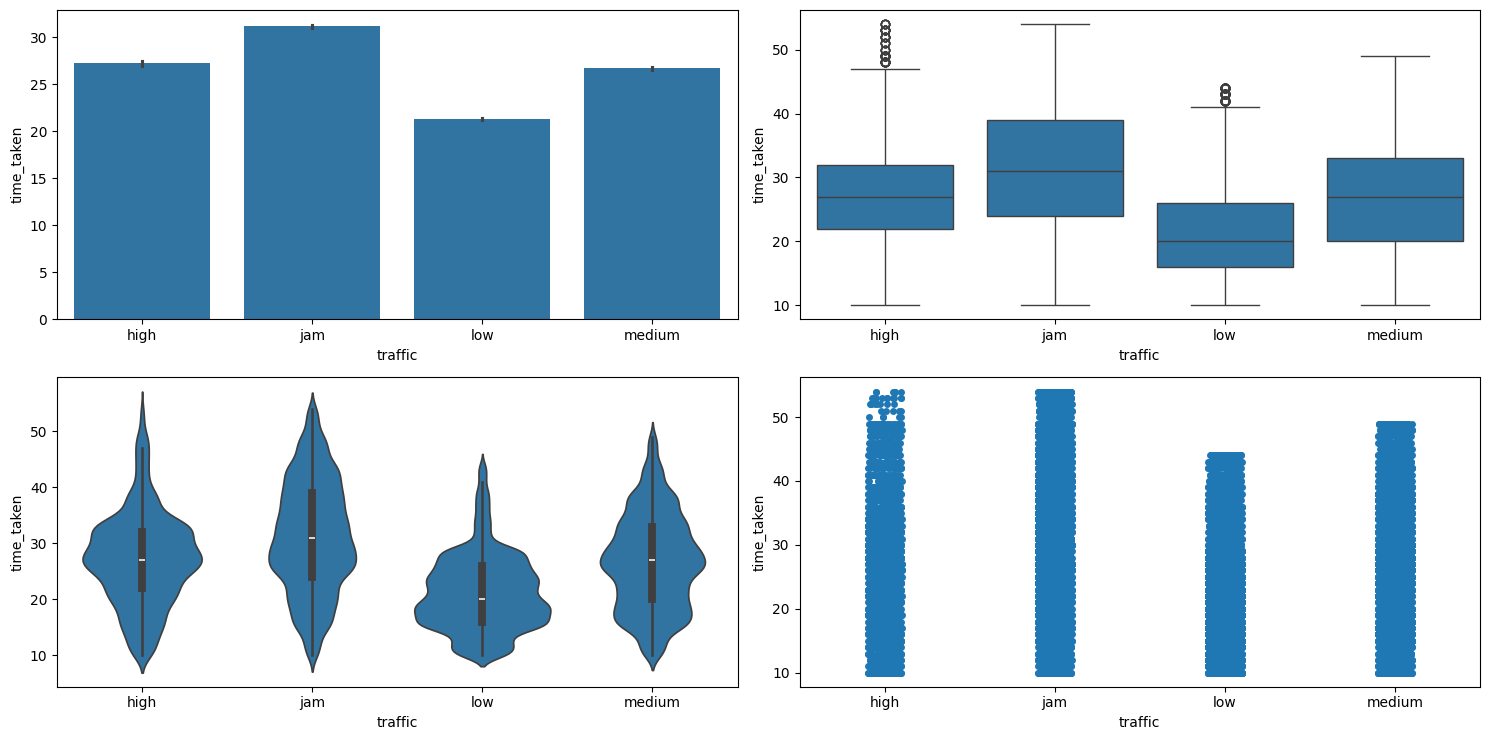

In [180]:
# does traffic affects delivery times

numerical_categorical_analysis(df, "traffic", "time_taken")

In [181]:
# hypothesis test on does traffic affects delivery times

anova_test(df, "time_taken", "traffic")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and traffic.


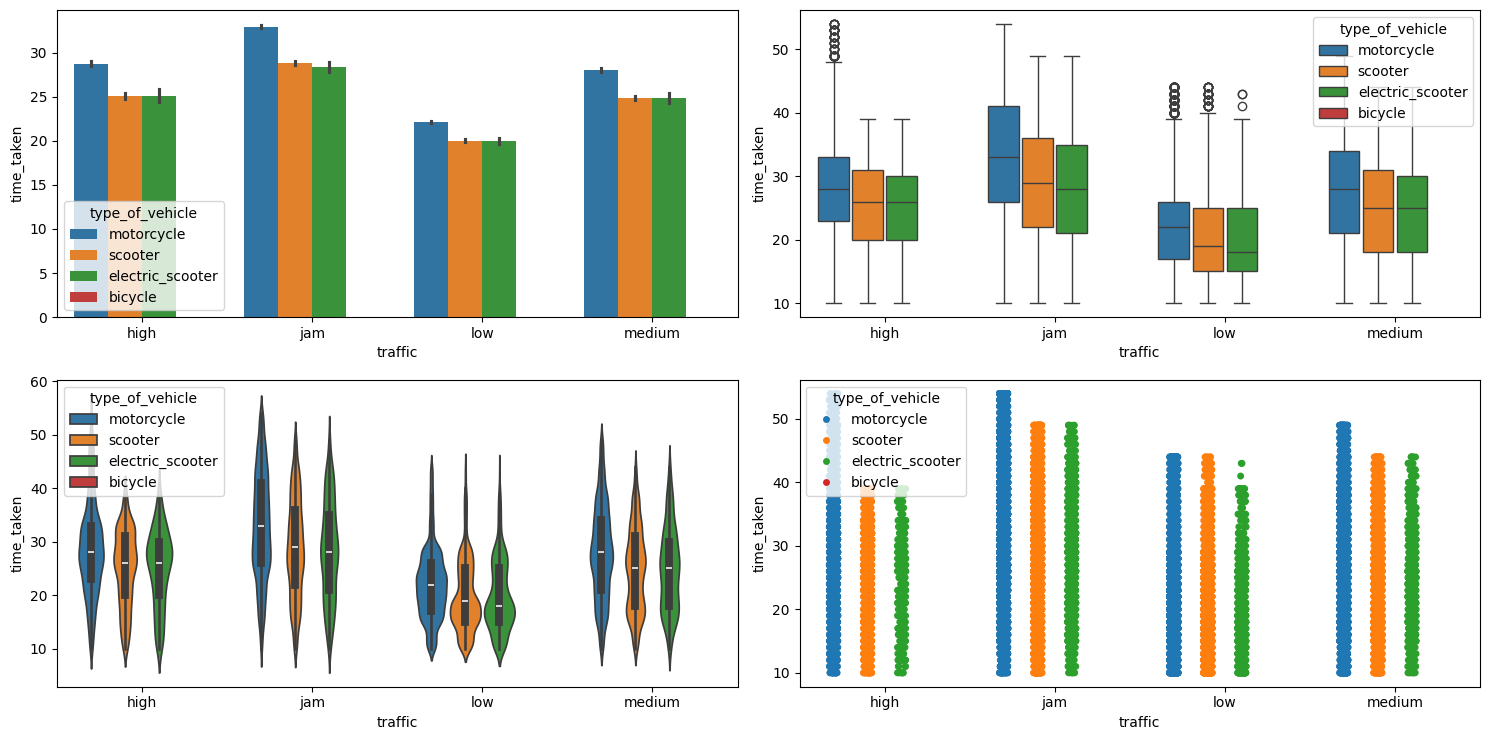

In [182]:
# are some vehicle types more suitable in traffic than others

multivariate_analysis(df, "time_taken", "traffic", "type_of_vehicle")

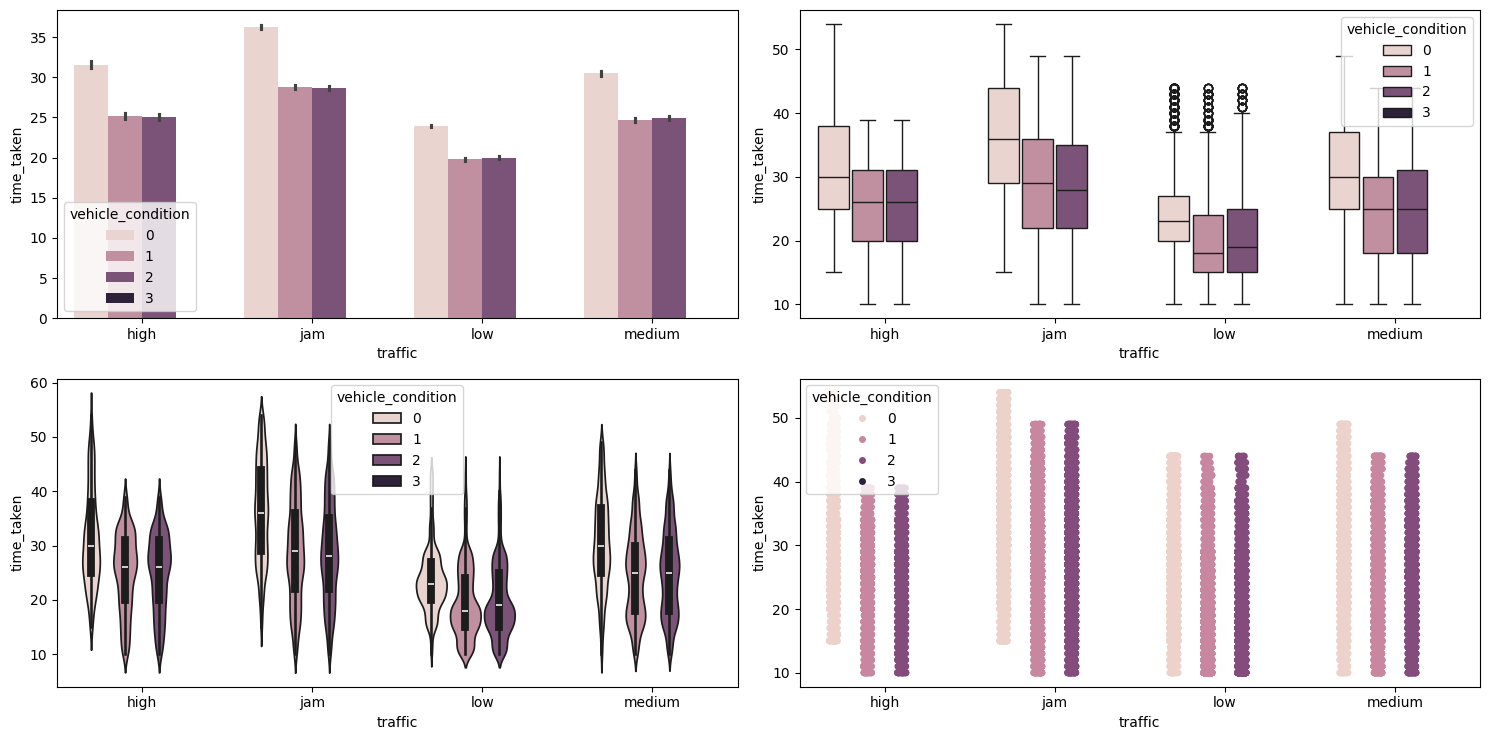

In [183]:
# does vehicle condition in traffic situations affects delivery times

multivariate_analysis(df, "time_taken", "traffic", "vehicle_condition")

**Dont make wrong interpretations that good condition vehicles takes longer times on avg**

This simply means that good vehicles are preferred for deliveries during festivals which results in longer delivery times

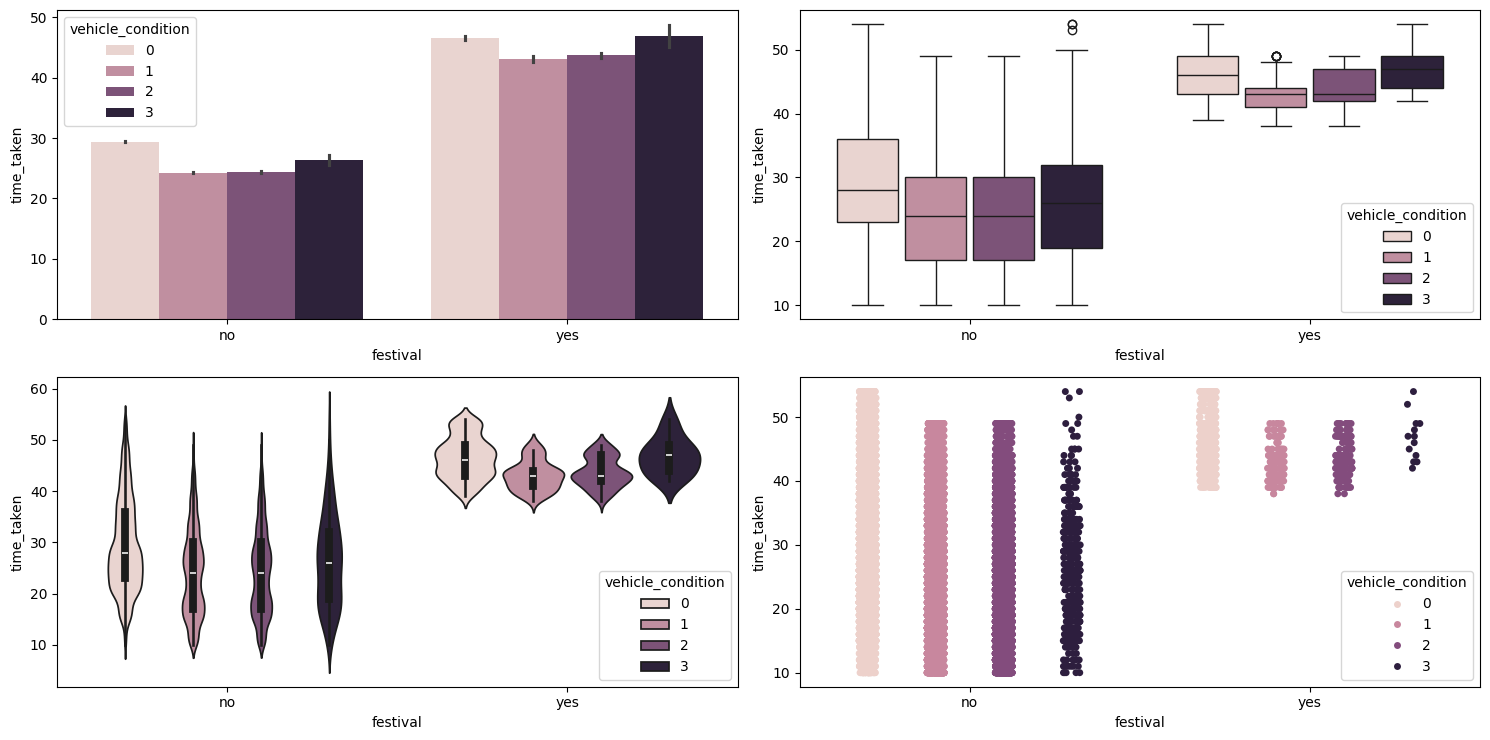

In [184]:
multivariate_analysis(df, "time_taken", "festival", "vehicle_condition")

# Multiple Deliveries

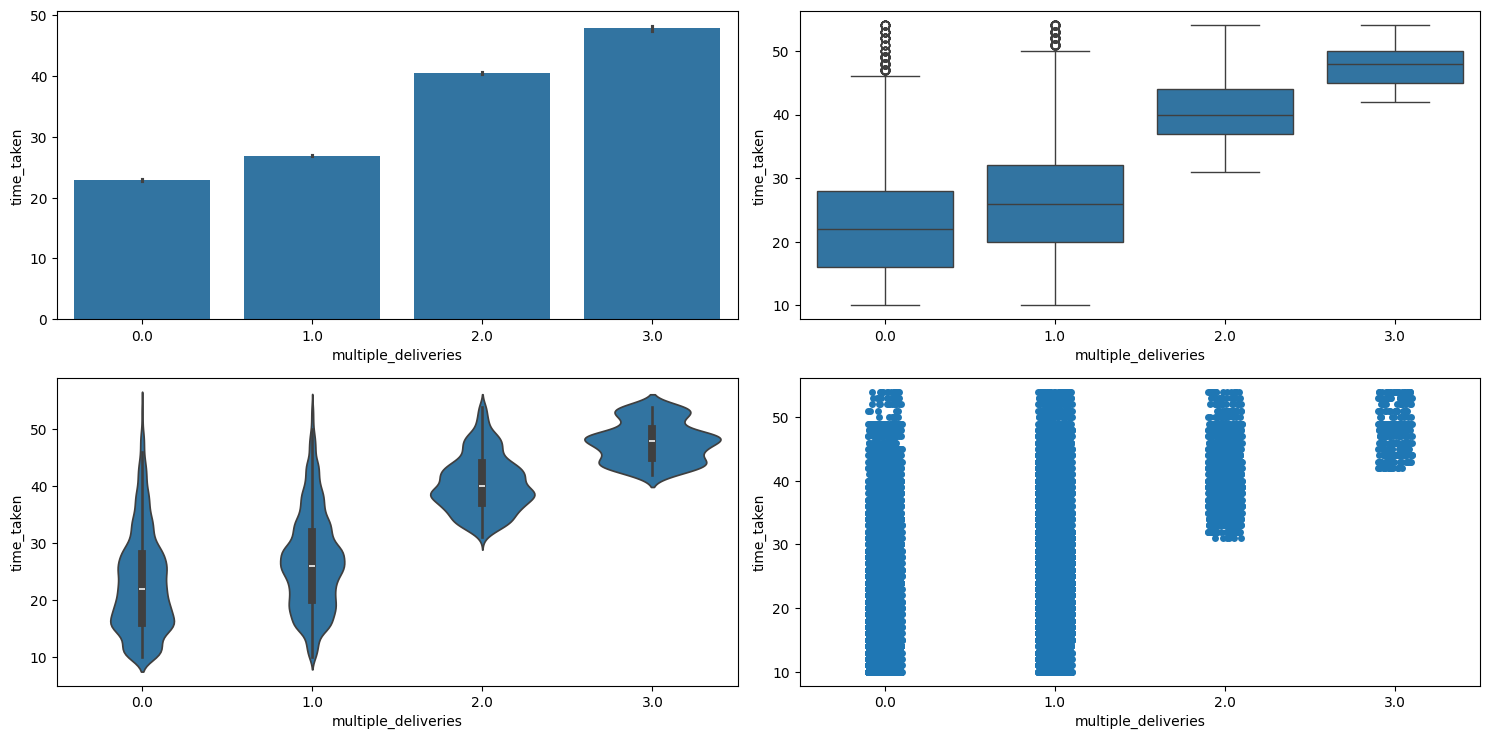

In [185]:
# does multiple delivereis affect delivery times

numerical_categorical_analysis(df, "multiple_deliveries", "time_taken")

In [186]:
# hypothesis test

anova_test(df, "time_taken", "multiple_deliveries")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and multiple_deliveries.


__Yes It does effect the time of delivery.__

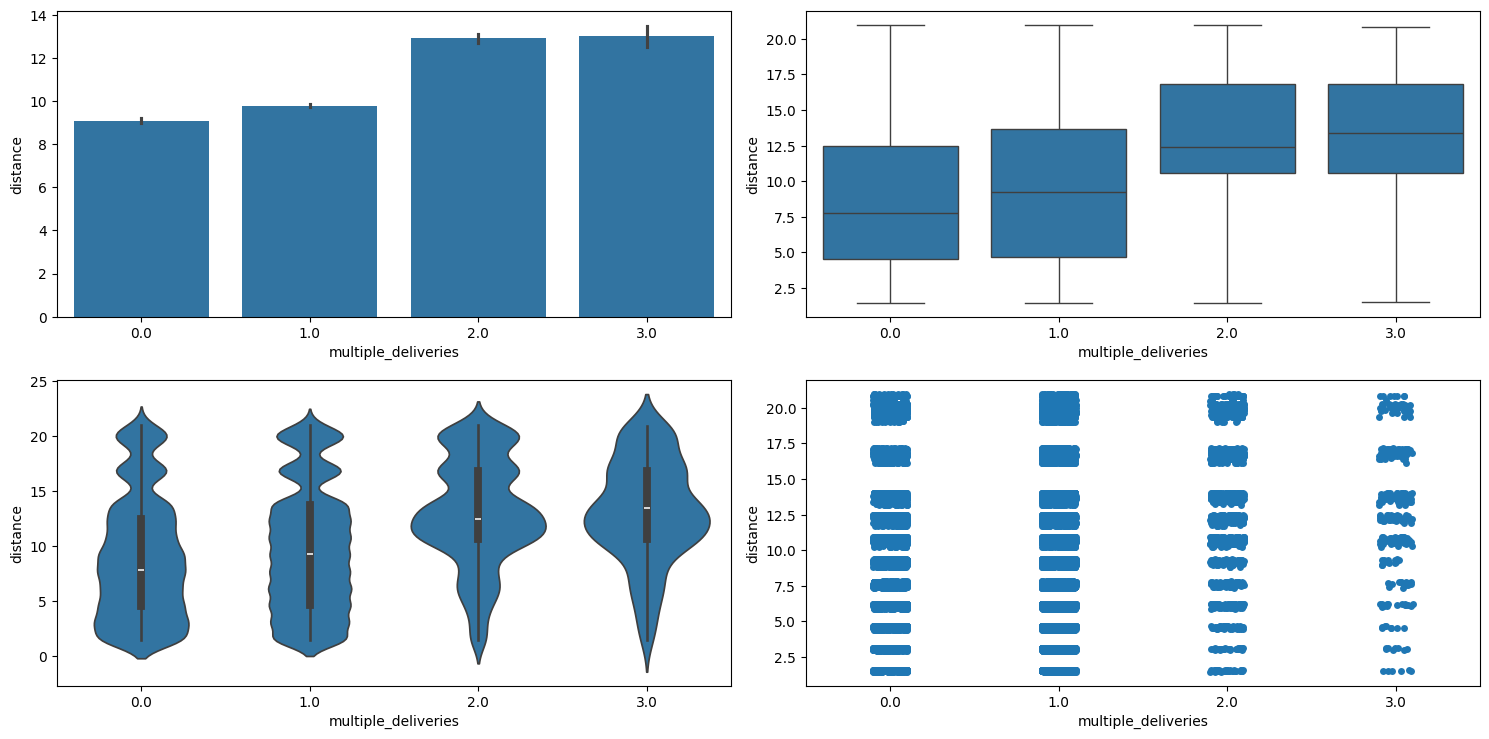

In [187]:
# do multiple deliveries are of longer distances

numerical_categorical_analysis(df, "multiple_deliveries", "distance")

In [188]:
# hypothesis test

anova_test(df, "distance", "multiple_deliveries")

5.109198421340492e-193
Reject the null hypothesis. There is a significant relationship between distance and multiple_deliveries.


# Weather

In [189]:
df['weather'].dtype

dtype('O')

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
The unique categories in weather column are ['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
**************************************************
The number of categories in weather column are 6


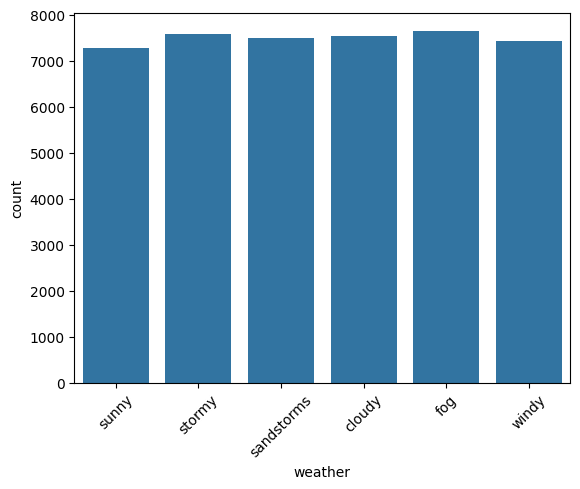

In [190]:
# categorical analysis on type of weather

categorical_analysis(df, "weather")

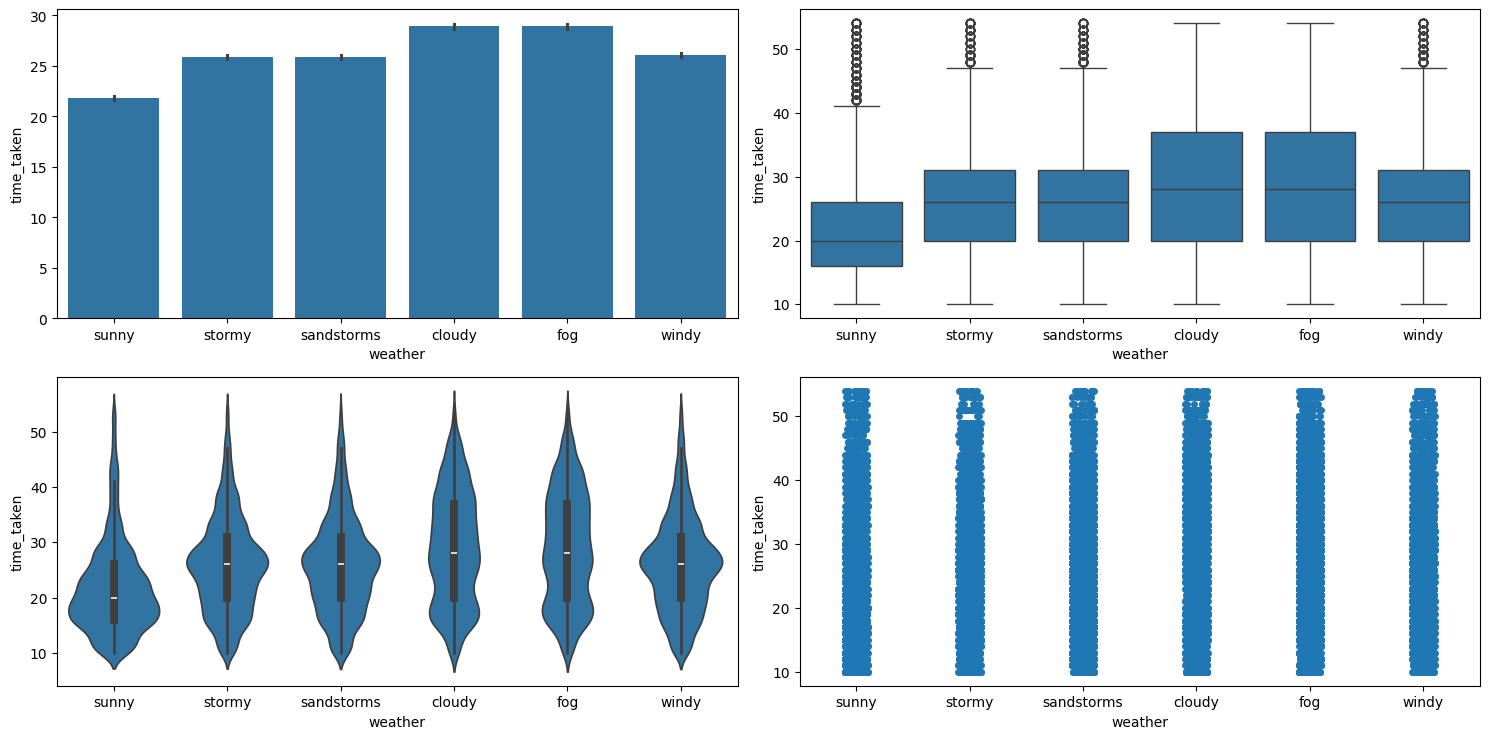

In [191]:
# does weather affect delivery times

numerical_categorical_analysis(df, "weather", "time_taken")

In [192]:
# hypothesis test

anova_test(df, "time_taken", "weather")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and weather.


In [193]:
# does the weather affects traffic

chi_2_test(df, "weather", "traffic")

0.4796388074753828
Fail to reject the null hypothesis. There is no significant association between weather and traffic.


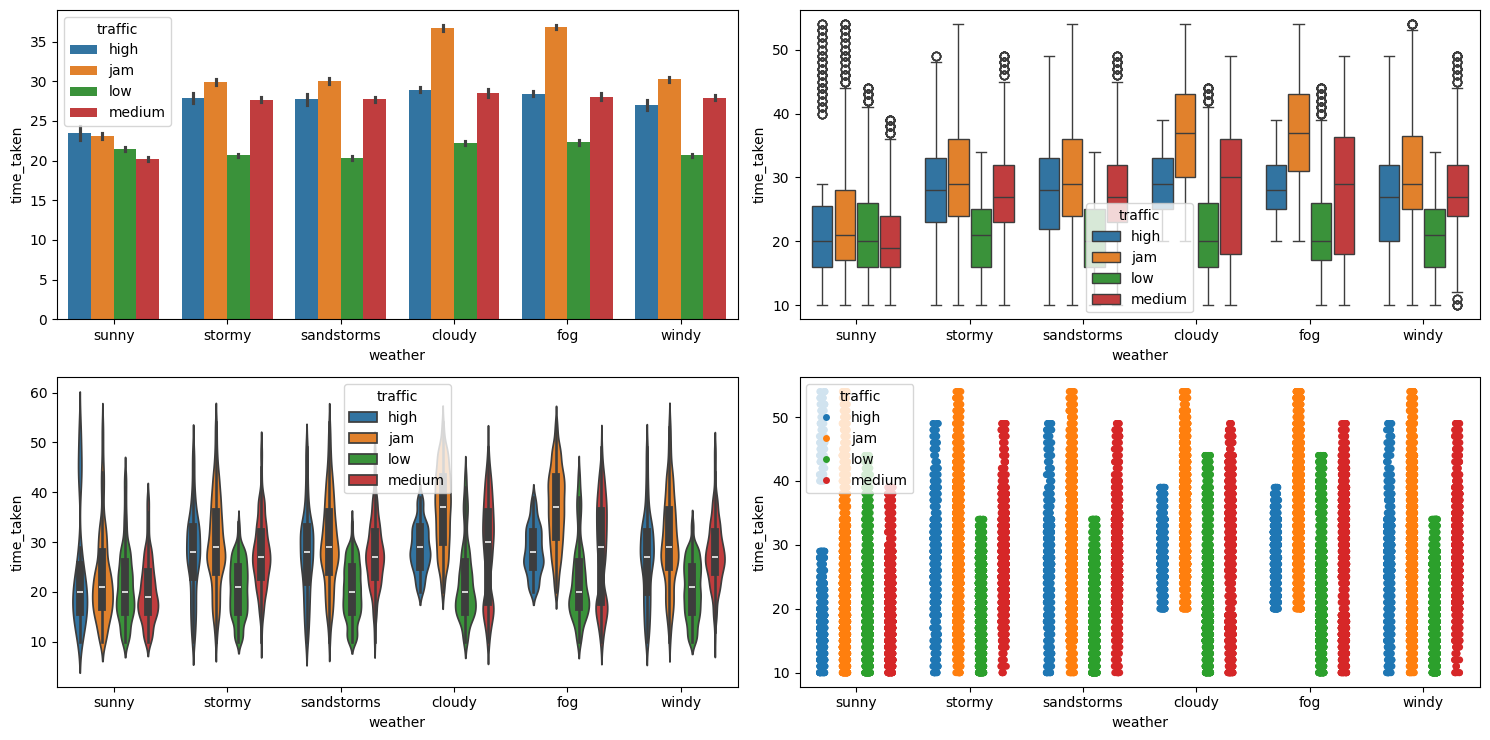

In [194]:
# delivery times based on weather and traffic

multivariate_analysis(df, "time_taken", "weather", "traffic")

**Seems like traffic along with other features combined acts as great discriminatory feature**

In [196]:
# pivot table

df.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


# Vehicle - Condition and Type

,Count,Percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


**************************************************
The unique categories in vehicle_condition column are [2, 0, 1, 3]
**************************************************
The number of categories in vehicle_condition column are 4


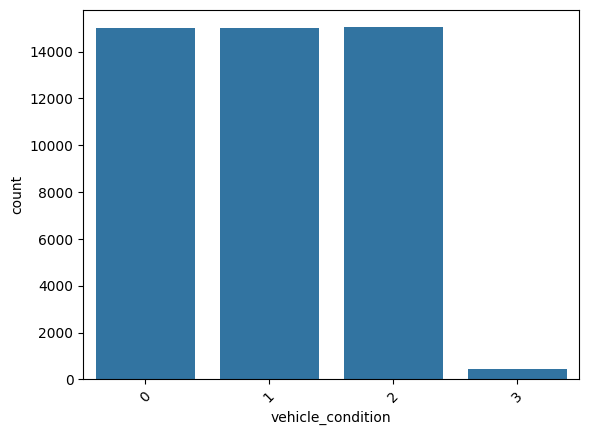

In [197]:
# categorical analysis on vehicle condition

categorical_analysis(df, "vehicle_condition")

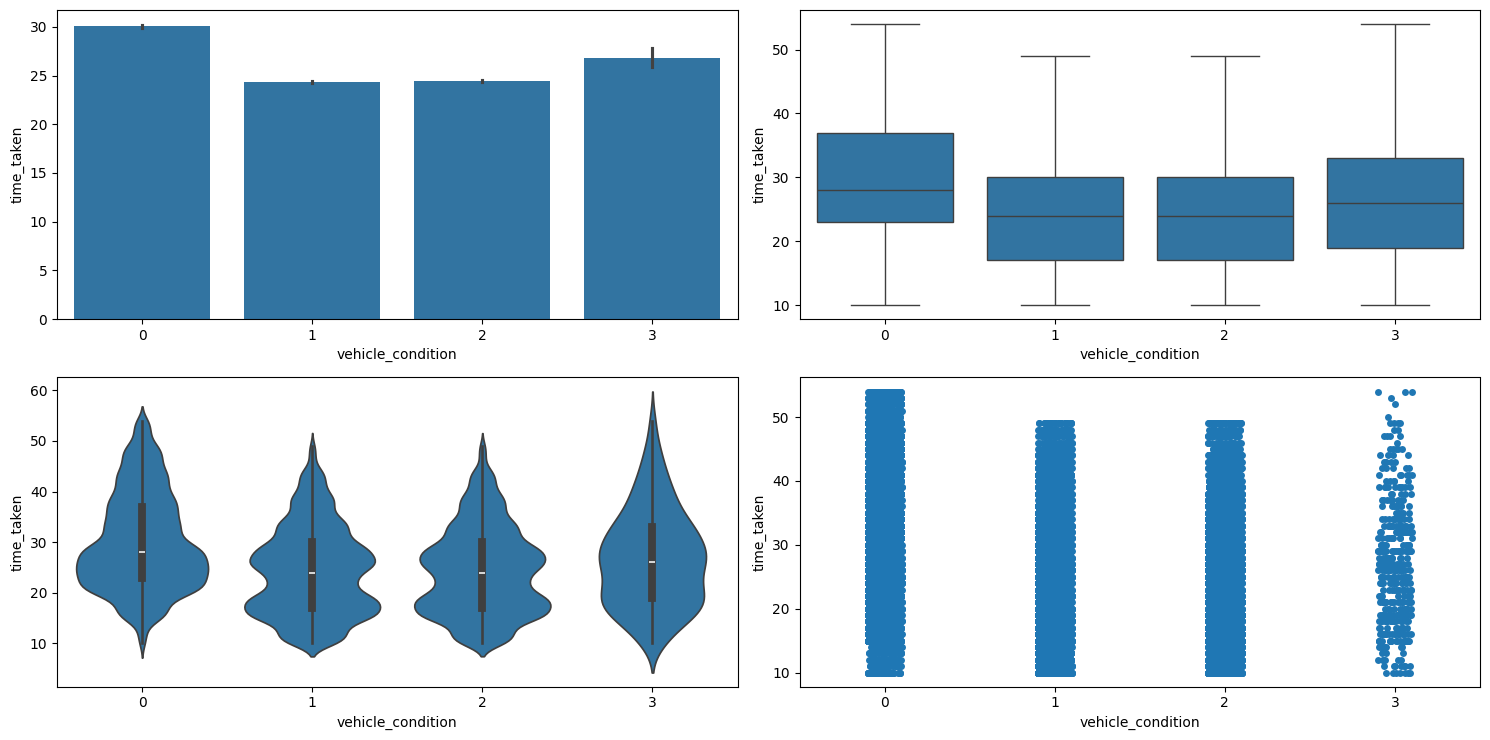

In [198]:
# does vehicle condition affect delivery times

numerical_categorical_analysis(df, "vehicle_condition", "time_taken")

In [199]:
# anova test

anova_test(df, "time_taken", "vehicle_condition")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and vehicle_condition.


,Count,Percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
The unique categories in type_of_vehicle column are ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
**************************************************
The number of categories in type_of_vehicle column are 4


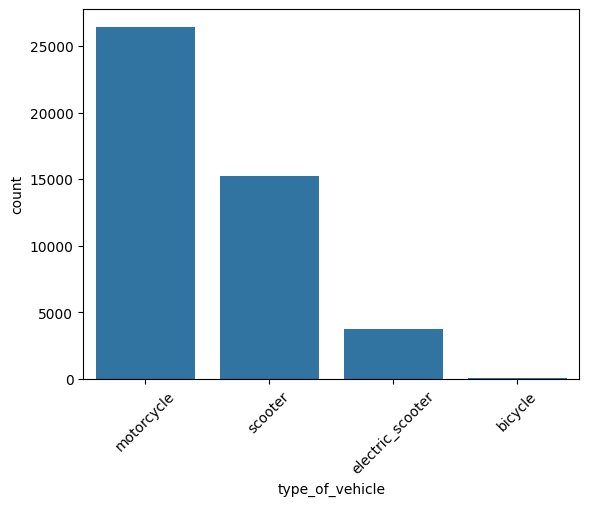

In [200]:
# analysis on vehicle type

categorical_analysis(df, "type_of_vehicle")

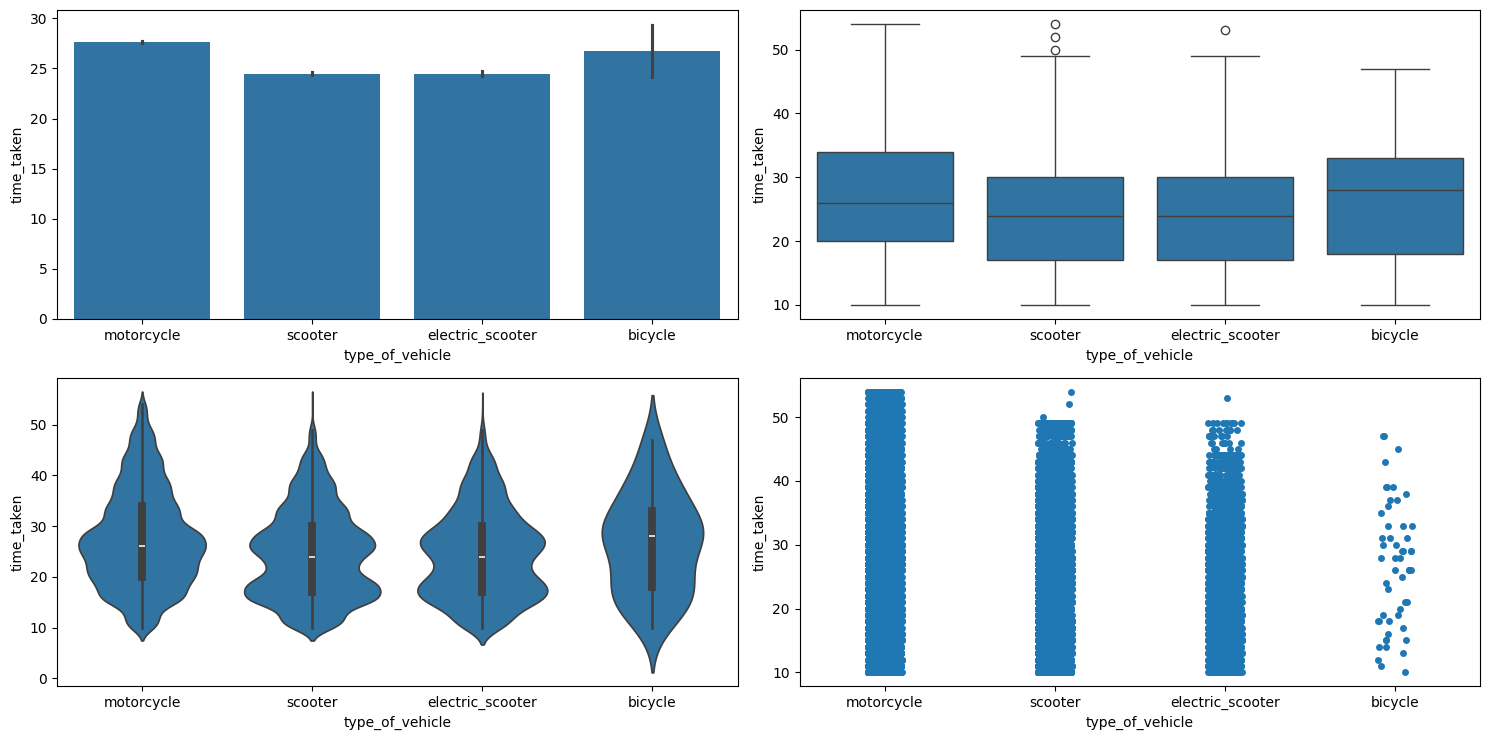

In [201]:
# does the type of vehicle affects delivery time

numerical_categorical_analysis(df, "type_of_vehicle", "time_taken")

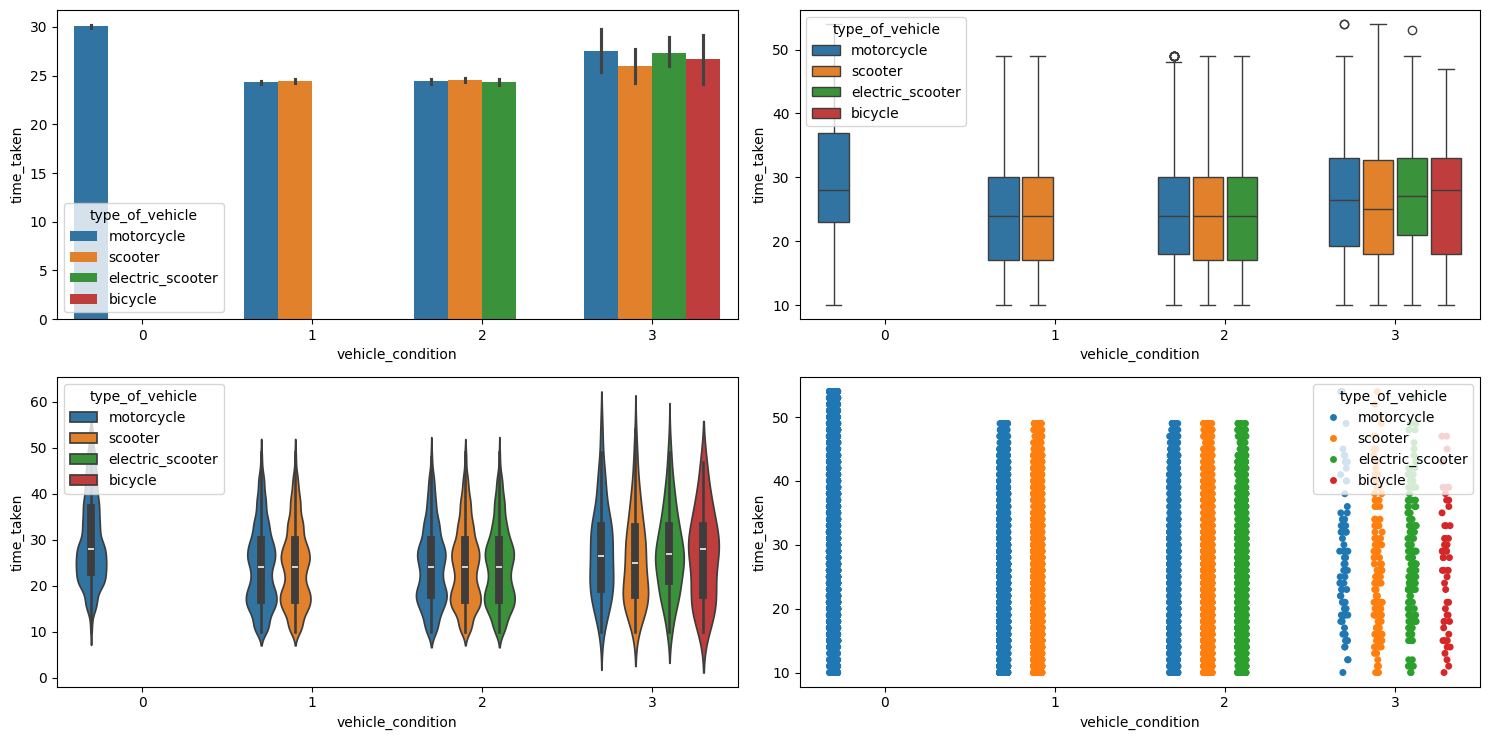

In [202]:
# vehicle condition and type

multivariate_analysis(df, "time_taken", "vehicle_condition", "type_of_vehicle")

In [203]:
# is their a relation between vehicle type and conditions

chi_2_test(df, "type_of_vehicle", "vehicle_condition")

0.0
Reject the null hypothesis. There is a significant association between type_of_vehicle and vehicle_condition.


# Type of Order

In [204]:
# type of order dtype

df['type_of_order'].dtype

dtype('O')

,Count,Percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


**************************************************
The unique categories in type_of_order column are ['snack', 'drinks', 'buffet', 'meal']
**************************************************
The number of categories in type_of_order column are 4


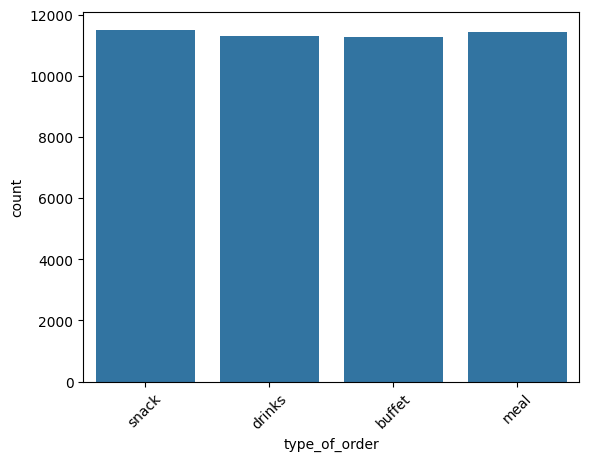

In [205]:
# analysis on type of order

categorical_analysis(df, "type_of_order")

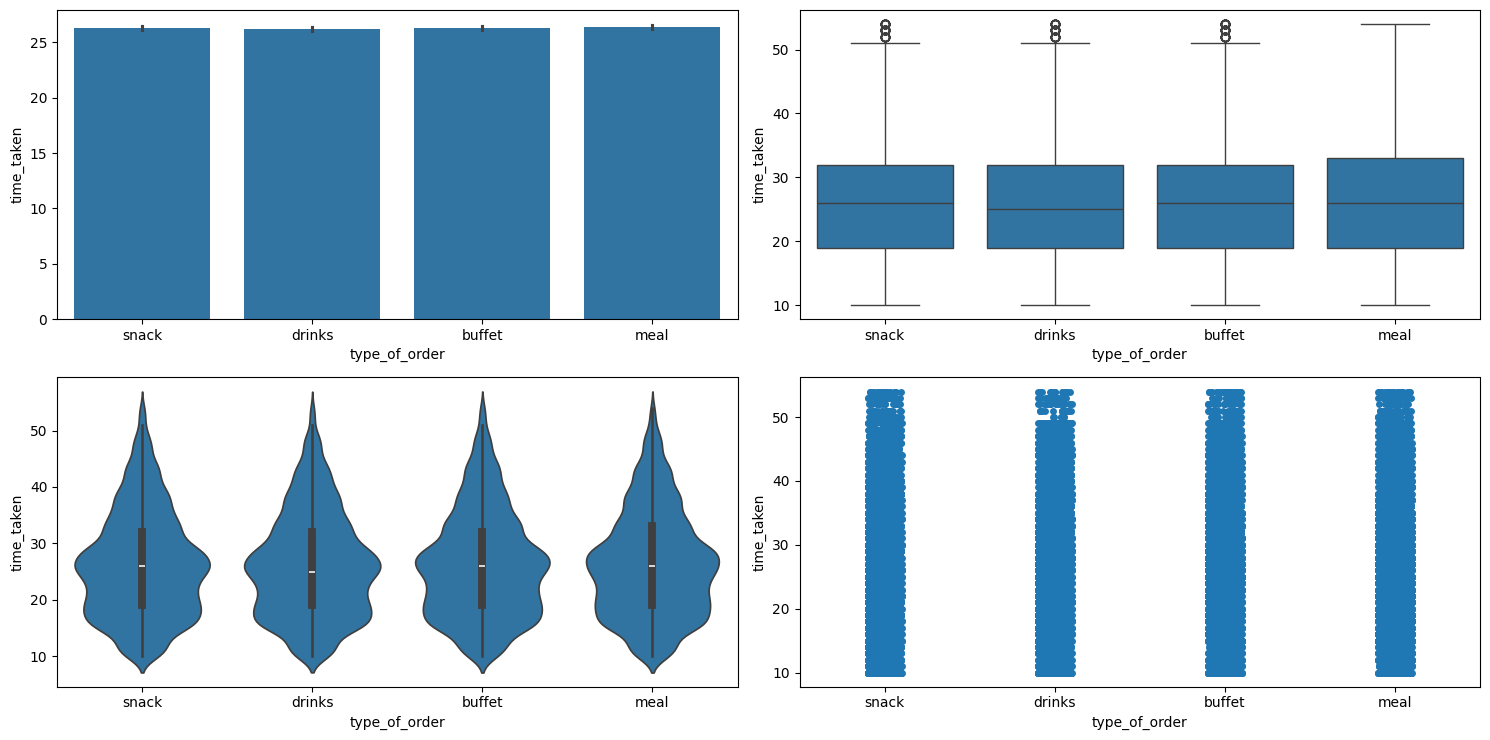

In [206]:
# does order type have have effect on delivery times

numerical_categorical_analysis(df, "type_of_order", "time_taken")

In [207]:
# hypothesis test

anova_test(df, "time_taken", "type_of_order")

0.30433098773146394
Fail to reject the null hypothesis. There is no significant relationship between time_taken and type_of_order.


In [209]:
# contingency table

pd.crosstab(df["type_of_order"],df["is_weekend"])

is_weekend,0,1
type_of_order,,
buffet,8238,3023
drinks,8130,3164
meal,8290,3145
snack,8337,3175


In [210]:
# does type of order have an effect over pickup time

chi_2_test(df,"pickup_time_minutes","type_of_order")

0.49118080317709845
Fail to reject the null hypothesis. There is no significant association between pickup_time_minutes and type_of_order.


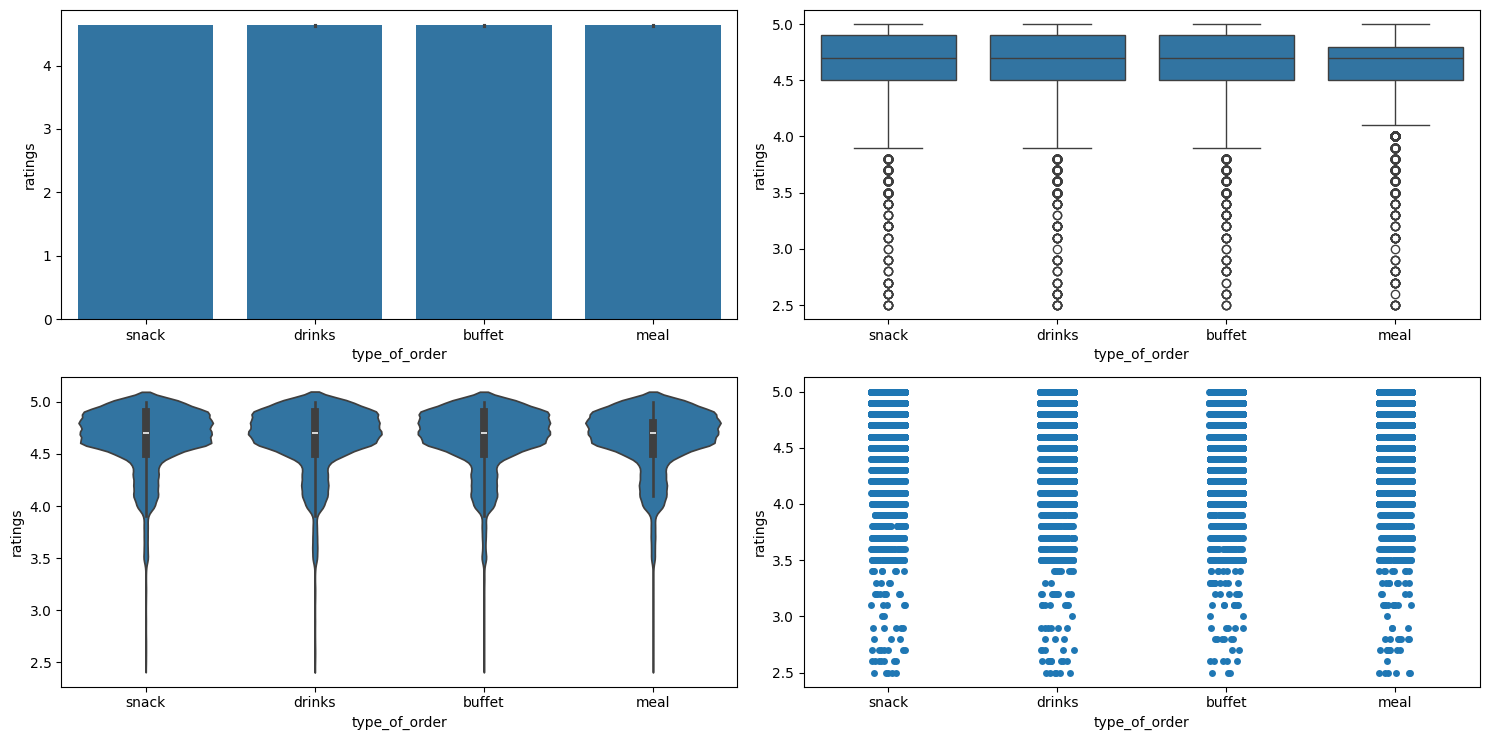

In [211]:
# does order type has an effect on ratings

numerical_categorical_analysis(df, "type_of_order", "ratings")

In [212]:
# is their a relationship between weekends and type of order

chi_2_test(df, "is_weekend", "type_of_order")

0.2658161540207276
Fail to reject the null hypothesis. There is no significant association between is_weekend and type_of_order.


In [213]:
# is their a relationship between festivals and type of order

chi_2_test(df, "festival", "type_of_order")

0.6149018072722126
Fail to reject the null hypothesis. There is no significant association between festival and type_of_order.


# city

In [214]:
df['city'].dtype

dtype('O')

,Count,Percentage
city,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


**************************************************
The unique categories in city column are ['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH', 'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA', 'AURG', 'AGR', 'VAD', 'ALH', 'BHP']
**************************************************
The number of categories in city column are 22


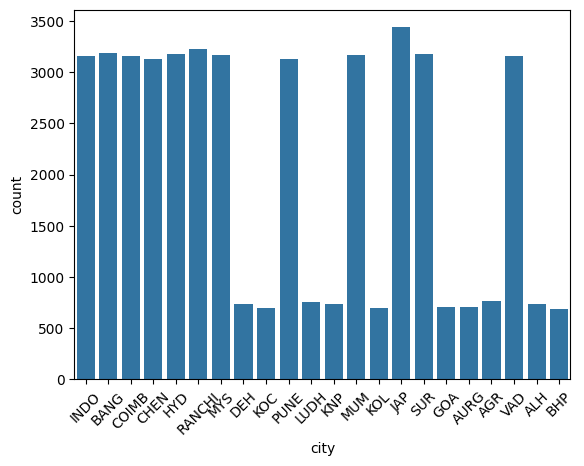

In [215]:
categorical_analysis(df,"city")

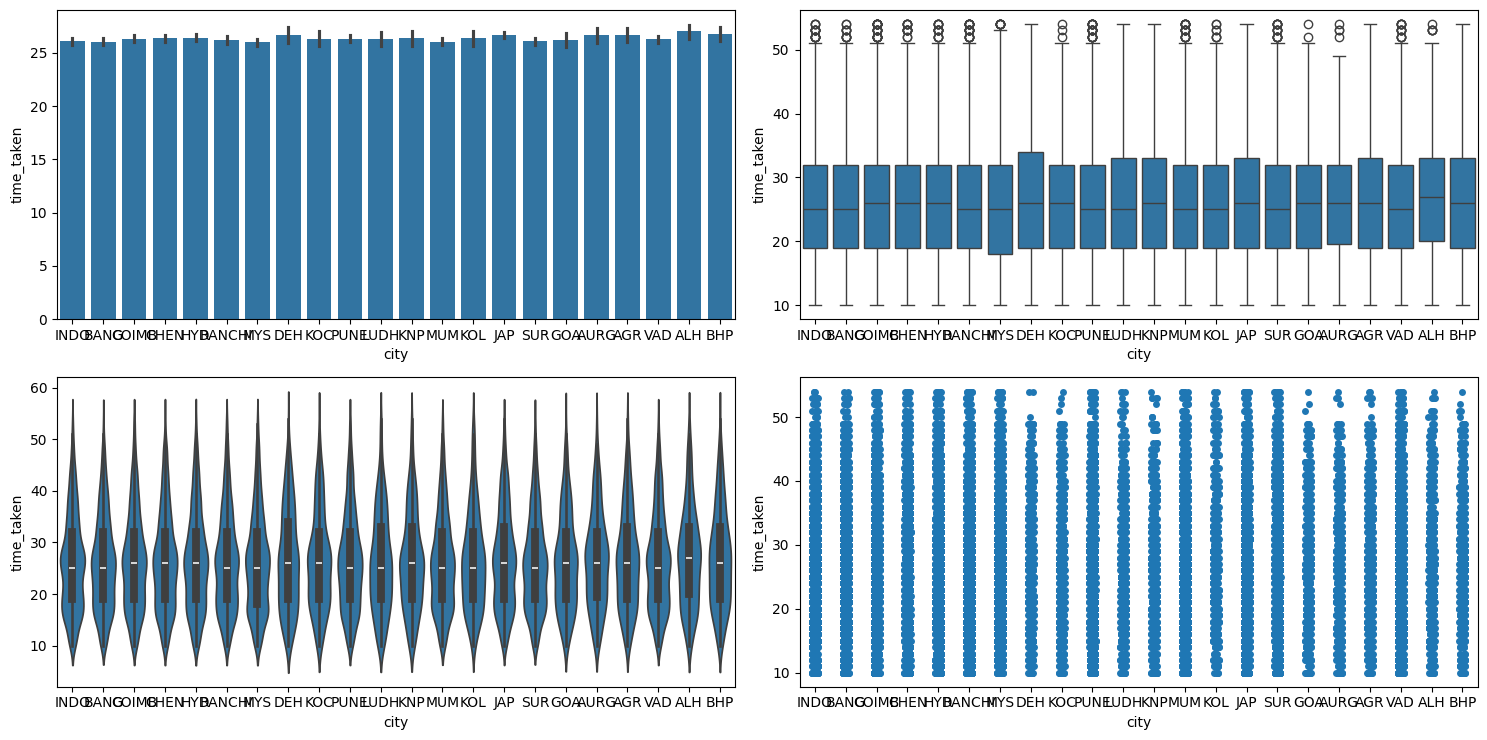

In [217]:
# does a city affects delivery times

numerical_categorical_analysis(df, "city", "time_taken")

In [224]:
# does city have a relationship with time taken

anova_test(df, "time_taken", "city")

0.15947192407563907
Fail to reject the null hypothesis. There is no significant relationship between time_taken and city.


__These is no such significant relationship.__

,Count,Percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


**************************************************
The unique categories in city_type column are ['urban', 'metropolitian', 'semi-urban', nan]
**************************************************
The number of categories in city_type column are 3


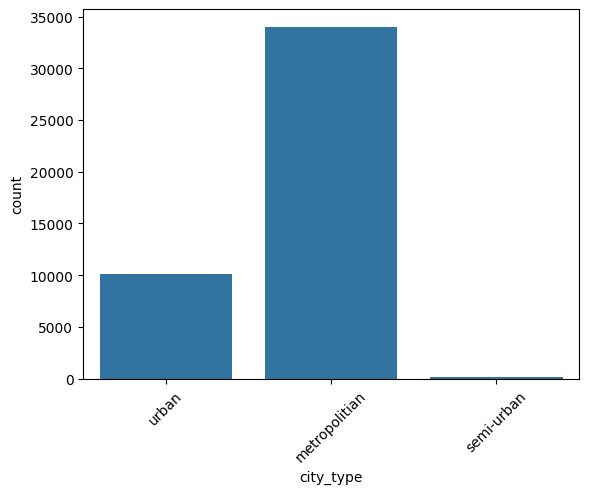

In [220]:
# categorical analysis on city type

categorical_analysis(df, "city_type")

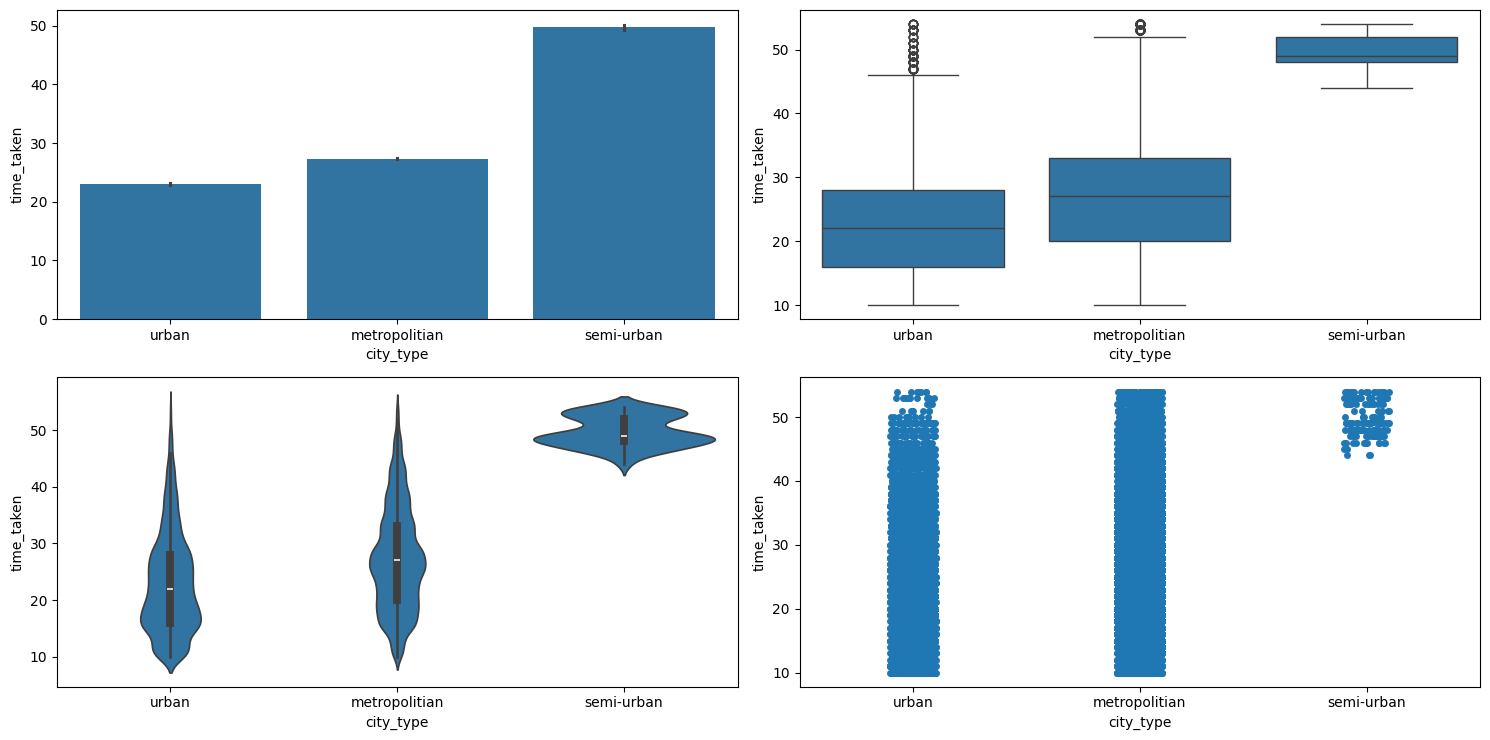

In [221]:
# does city types affect delivery times

numerical_categorical_analysis(df, "city_type", "time_taken")

In [222]:
# hypothesis test

anova_test(df, "time_taken", "city_type")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and city_type.


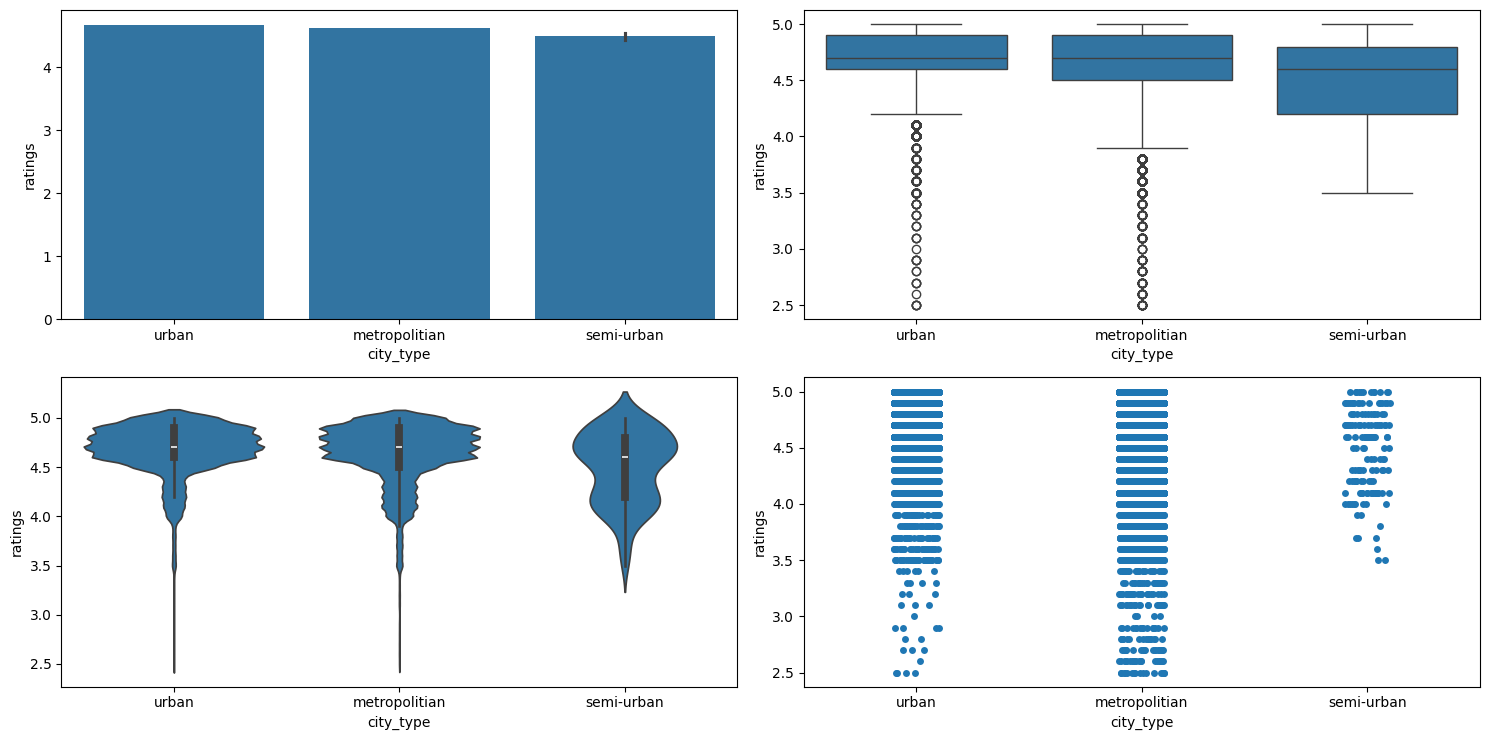

In [225]:
# does city type affects rider ratings

numerical_categorical_analysis(df, "city_type", "ratings")

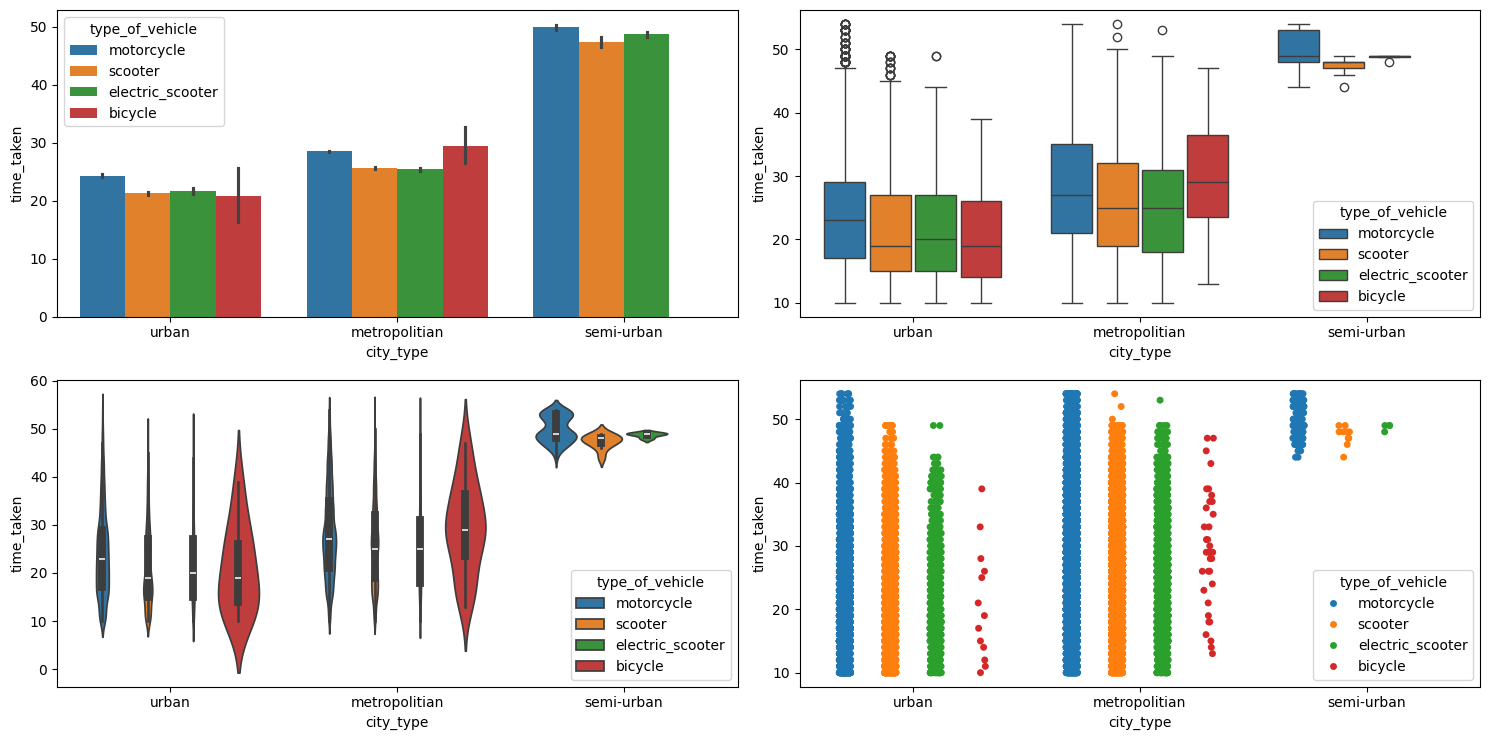

In [226]:
# city type, type of vehicle and delivery time analysis

multivariate_analysis(df, "time_taken", "city_type", "type_of_vehicle")

# Distance

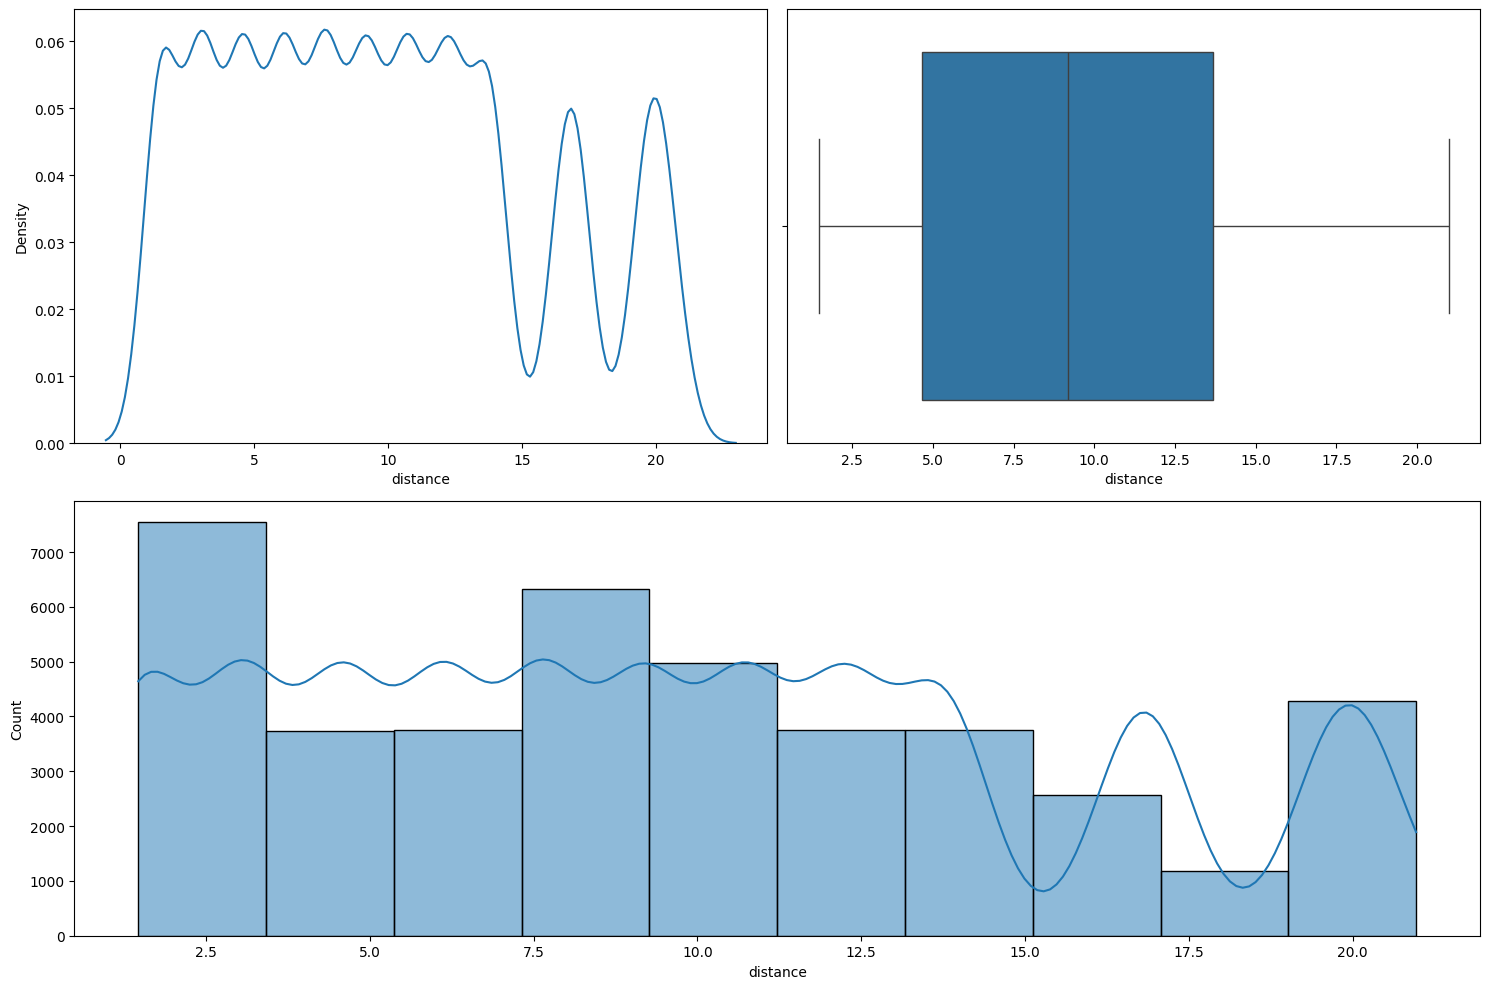

In [227]:
# numerical analysis of distance

numerical_analysis(df, "distance",bins=10)

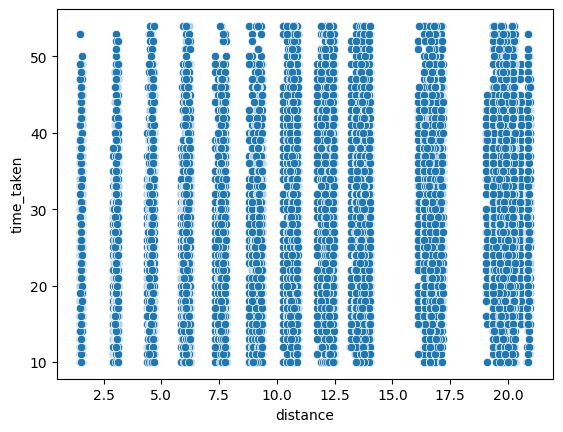

In [228]:
# relationship between distance and delivery times

sns.scatterplot(df,x="distance",y="time_taken")
plt.show()

In [229]:
# corr

df[["distance","time_taken"]].corr()

,distance,time_taken
distance,1.000000,0.320705
time_taken,0.320705,1.000000


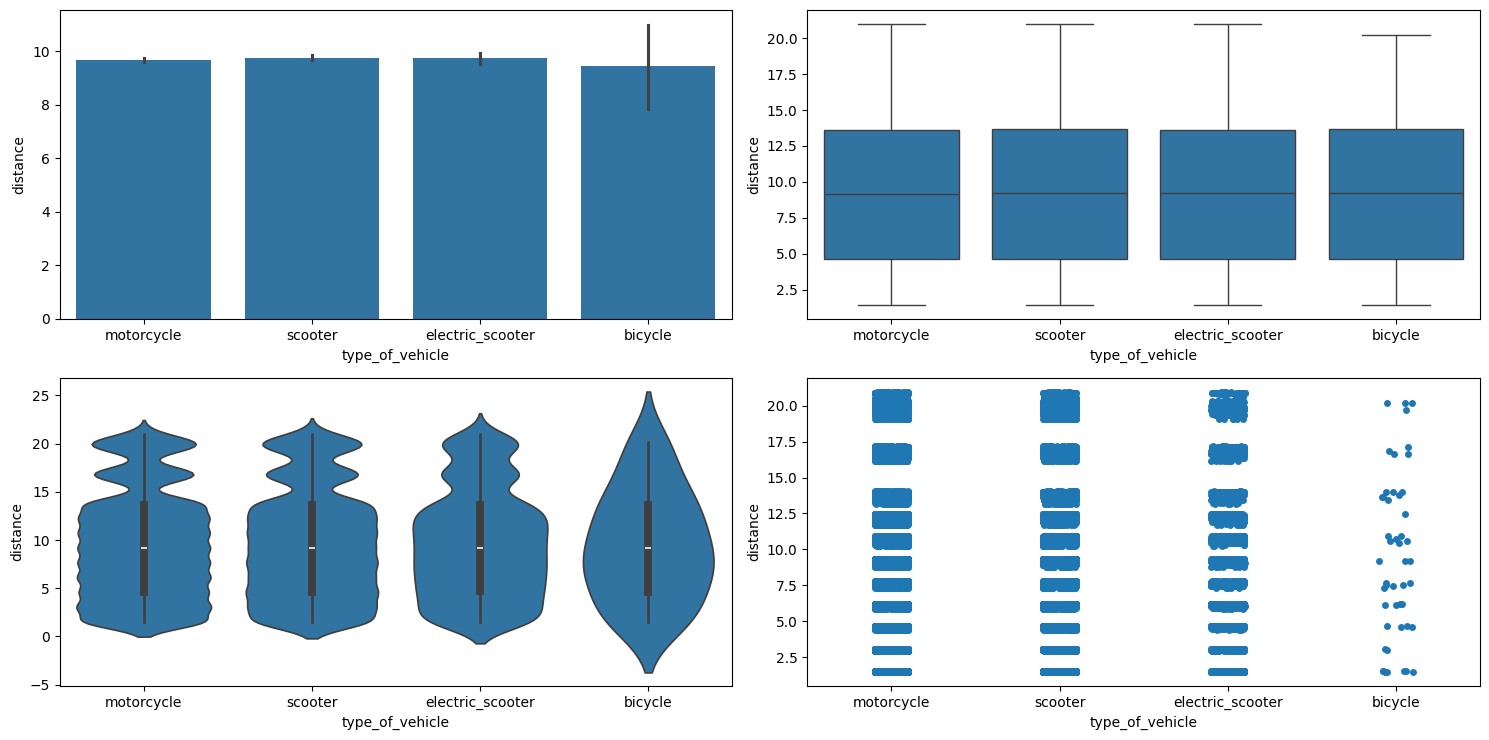

In [230]:
# vehicle type and distance analysis

numerical_categorical_analysis(df, "type_of_vehicle", "distance")

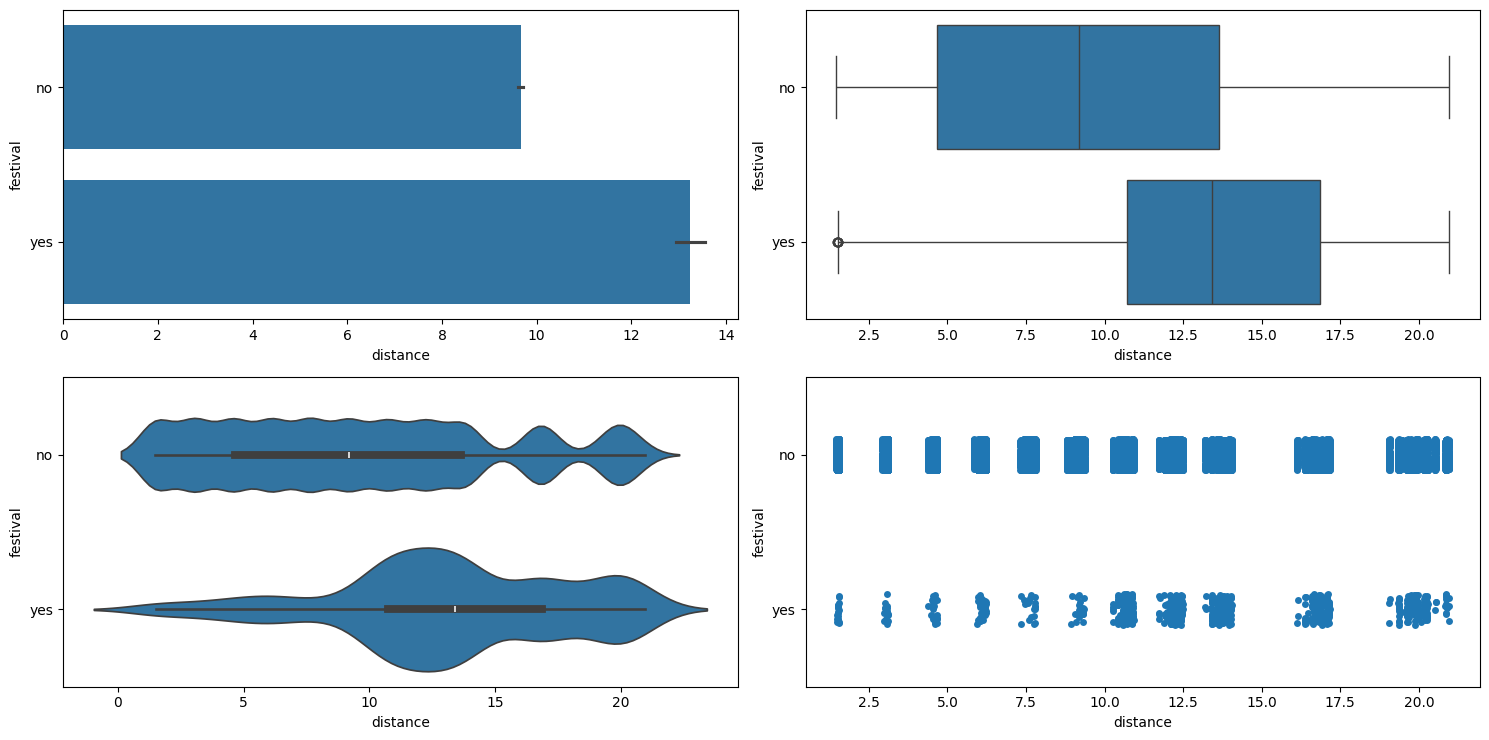

In [231]:
# do riders cover more distances during festivals

numerical_categorical_analysis(df, "distance", "festival")

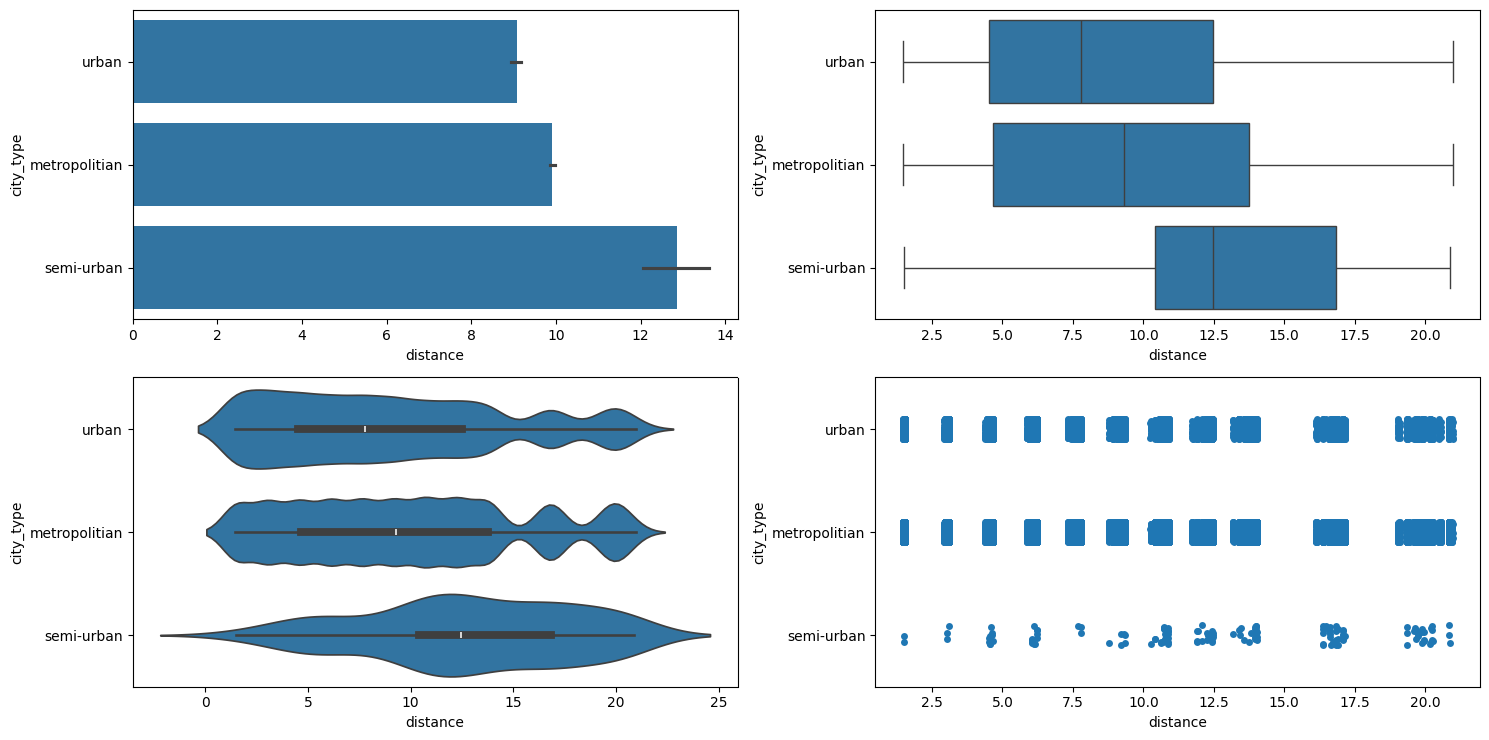

In [232]:
# distance and city type

numerical_categorical_analysis(df, "distance", "city_type")

In [236]:
# new feature based on distance

df = df.assign(
                        distance_type = pd.cut(df["distance"],bins=[0,5,10,15,25],
                                               right=False,labels=["short","medium","long","very_long"])
                                    )

In [239]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'order_time_hour',
       'pickup_time_minutes', 'order_time_of_day', 'distance', 'time_taken_pt',
       'distance_type'],
      dtype='object')

In [238]:
df.sample(5)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,order_day,order_month,order_day_of_week,is_weekend,order_time_hour,pickup_time_minutes,order_time_of_day,distance,time_taken_pt,distance_type
19249,COIMBRES02DEL02,37.0,4.5,11.022477,76.995667,11.072477,77.045667,2022-03-07,sunny,medium,...,7,3,Monday,0,18.0,15.0,evening,7.790157,-0.606845,medium
15977,PUNERES19DEL02,38.0,4.9,18.563934,73.915367,18.613934,73.965367,2022-03-17,windy,low,...,17,3,Thursday,0,23.0,10.0,night,7.660317,0.193619,medium
35544,MUMRES07DEL01,25.0,5.0,19.091458,72.827808,19.131458,72.867808,2022-03-30,sandstorms,medium,...,30,3,Wednesday,0,16.0,10.0,afternoon,6.119245,-0.361298,medium
1456,MYSRES14DEL02,36.0,4.8,NaN,NaN,NaN,NaN,2022-03-15,sunny,medium,...,15,3,Tuesday,0,17.0,10.0,afternoon,NaN,-0.869203,NaN
39502,SURRES01DEL02,30.0,4.8,21.186438,72.794115,21.206438,72.814115,2022-03-07,sandstorms,low,...,7,3,Monday,0,8.0,10.0,morning,3.040542,-0.482135,short


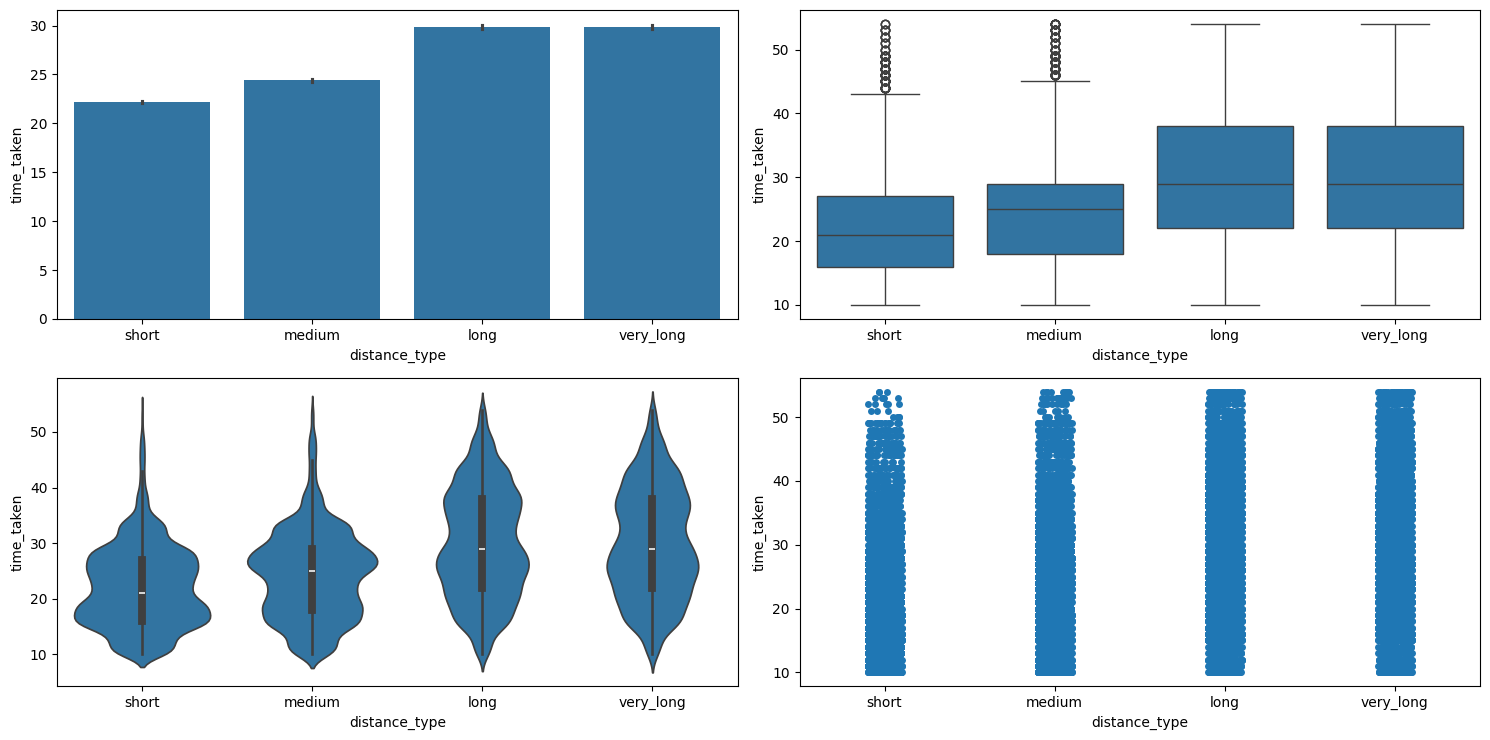

In [240]:
# does distance type affects delivery times

numerical_categorical_analysis(df, "distance_type", "time_taken")

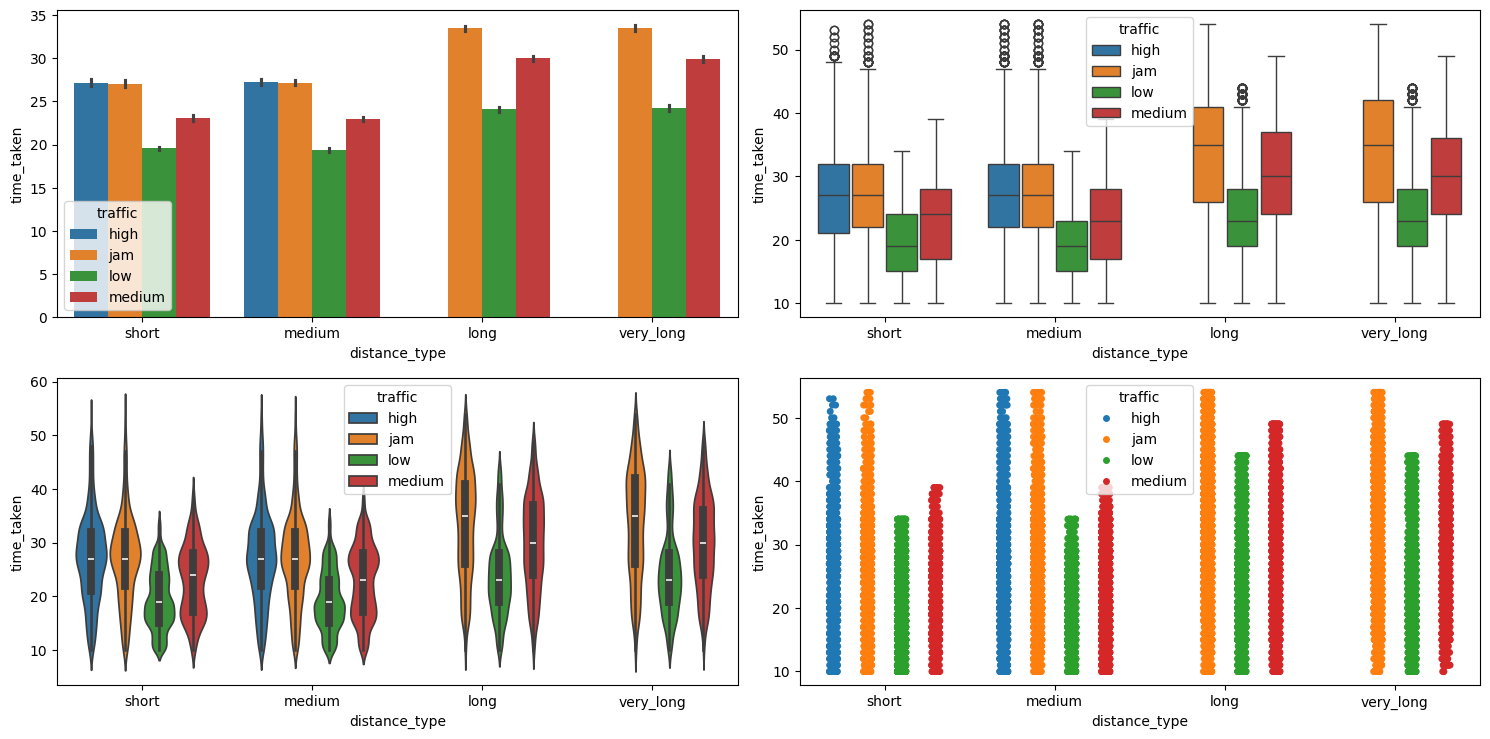

In [241]:
# delivery times based on distance and traffic

multivariate_analysis(df, "time_taken", "distance_type", "traffic")